In [95]:
import anndata
import numpy as np
import seaborn as sb
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import scanpy as sc
warnings.filterwarnings("ignore")
import random
from genes2genes import Main
from genes2genes import ClusterUtils
from genes2genes import TimeSeriesPreprocessor
from genes2genes import PathwayAnalyser
from genes2genes import VisualUtils

In [34]:
adata = anndata.read_h5ad('/sc/arion/projects/CommonMind/aging/hui/submission/files/integrated_EN_con_adata.h5ad')
#subtypes_to_keep= ["PN_dev", "L2-3_CUX2_dev-fetal", "L2-3_CUX2_dev-4", "L2-3_CUX2_dev-6", "L2-3_CUX2_dev-2", "L2-3_CUX2_dev-3", "L2-3_CUX2_dev-5", "L2-3_CUX2_dev-1", "L2_CUX2_LAMP5_dev", "L2_CUX2_LAMP5", "L3_CUX2_PRSS12", "EN_L2_3_IT_NTNG1", "EN_L2_3_IT_PDGFD"]
#subtypes_to_keep= ["PN_dev"]
#adata=adata[adata.obs.subtype_uni.isin(subtypes_to_keep)]

adata.obs['stage_id'] = adata.obs['stage_id'].str.replace(r'(Middle|Late|Young)_Adulthood', 'Adulthood', regex=True)
#adata.obs.stage_id.value_counts()

In [96]:
n_cells = int(5000/6)
random.seed(0)
adata.obs['stage_id'] = adata.obs['stage_id'].astype(str)

sampled_indices = (
    adata.obs.groupby('stage_id', group_keys=False)
    .apply(lambda x: x.sample(n=min(len(x), n_cells), random_state=0))
    .index
)

adata_ref = adata[sampled_indices].copy()

In [97]:
adata_ref.X=adata_ref.layers["raw-cts_pre-ds"]


sc.pp.filter_cells(adata_ref, min_genes=500)
sc.pp.filter_genes(adata_ref, min_cells=5)
# Normalizing to median total counts
sc.pp.normalize_total(adata_ref,target_sum=1e6)
# Logarithmize the data
sc.pp.log1p(adata_ref)

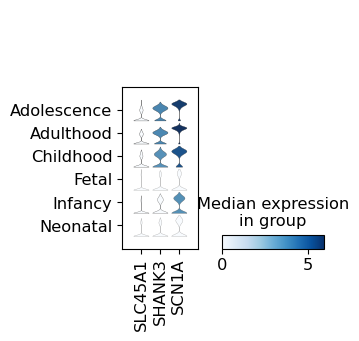

In [98]:
markers = ['SLC45A1','SHANK3','SCN1A']#TCF4
sc.pl.stacked_violin(adata_ref, markers, groupby='stage_id', save='g2g_psychad_violin.pdf')

#sc.pl.violin(adata, keys='SHANK3', groupby='stage_id', rotation=90)

In [99]:
ref_psedotime = pd.read_table('./data/psychad.meta.txt')
cells_ref=adata_ref.obs.index.intersection(ref_psedotime.index) 
adata_ref=adata_ref[cells_ref]
adata_ref.obs['time']=ref_psedotime.loc[adata_ref.obs.index,'time']


In [100]:

#adata_query = anndata.read_h5ad('/sc/arion/projects/CommonMind/roussp01a/ENT/snRNAseq/qc_scanpy/ent_nn_merge.h5ad')
adata_query = anndata.read_h5ad('/sc/arion/projects/CommonMind/roussp01a/ENT/snRNAseq/qc_scanpy/ent_goldstein_merge_rawcount.h5ad')
sc.pp.filter_cells(adata_query, min_genes=500)
sc.pp.filter_genes(adata_query, min_cells=5)

# Normalizing to median total counts
sc.pp.normalize_total(adata_query,target_sum=1e6)
# Logarithmize the data
sc.pp.log1p(adata_query)


In [101]:
#query_psedotime = pd.read_table('./data/integrate_entnn_pseduotime_meta.txt')
query_psedotime = pd.read_table('/sc/arion/projects/roussp01a/liting/Olf/data/integrate_entgoldstein_pseduotime_meta.txt')

In [102]:
adata_query=adata_query[query_psedotime.index]
adata_query.obs['time']=query_psedotime.loc[adata_query.obs.index,'monocle3_pseudotime']
adata_query.obs['pseudotime']=query_psedotime.loc[adata_query.obs.index,'monocle3_pseudotime']#sling_pseudotime#monocle3_pseudotime
adata_query.obs['N_types']=query_psedotime.loc[adata_query.obs.index,'cca_N_types']
adata_query.obs['N_types_stage']=query_psedotime.loc[adata_query.obs.index,'cca_N_types_stage']



In [103]:
adata_ref.obs['time'] = TimeSeriesPreprocessor.Utils.minmax_normalise(np.asarray(adata_ref.obs['time']))
adata_query.obs['time'] = TimeSeriesPreprocessor.Utils.minmax_normalise(np.asarray(adata_query.obs['time']))

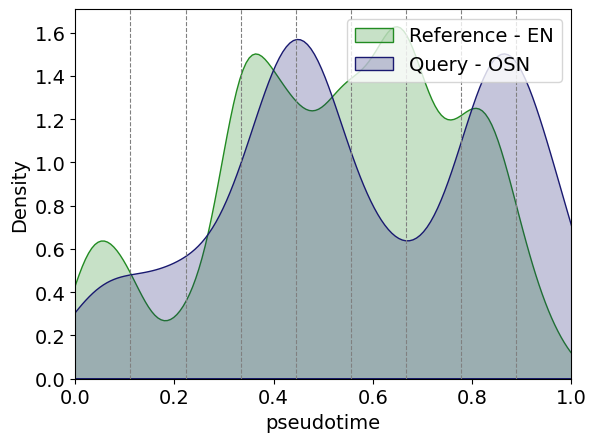

In [104]:
# Visualize thcolumnsseudotime distributions
sb.kdeplot(adata_ref.obs['time'], fill=True, label='Reference - EN', color='forestgreen') 
sb.kdeplot(adata_query.obs['time'], fill=True, label='Query - OSN', color='midnightblue'); 
plt.xlim(0, 1)
x_min, x_max = plt.xlim()
num_lines = 8
line_positions = np.linspace(x_min, x_max, num_lines + 2)[1:-1]  # Exclude the endpoints

# Add vertical lines
for pos in line_positions:
    plt.axvline(x=pos, color='gray', linestyle='--', linewidth=0.8)

# Show the plot
plt.xlabel('pseudotime'); plt.legend(); plt.show()
# Calculate the x-axis limits and add vertical lines


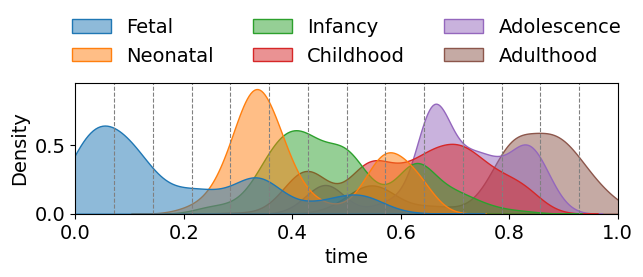

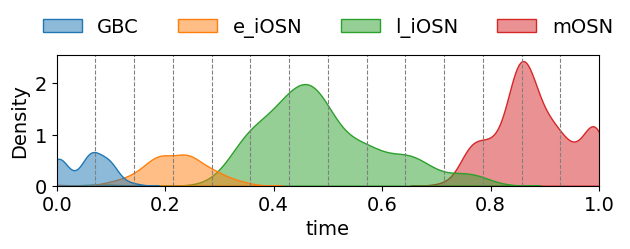

In [105]:
adata_ref.obs['stage_id'] = pd.Categorical(adata_ref.obs['stage_id'], 
                            categories=['Fetal', 'Neonatal','Infancy', 'Childhood','Adolescence','Adulthood'], 
                            ordered=True)


plt.figure(figsize=(7, 1.7))  # 8 inches wide and 6 inches tall

#ax=sb.kdeplot(data=adata_ref.obs, x='time', hue='stage_id', fill=True, alpha=0.5,palette="crest")
ax=sb.kdeplot(data=adata_ref.obs, x='time', hue='stage_id', fill=True, alpha=0.5)
plt.xlim(0, 1)

# Calculate the x-axis limits and add vertical lines
x_min, x_max = plt.xlim()
num_lines = 13
line_positions = np.linspace(x_min, x_max, num_lines + 2)[1:-1]  # Exclude the endpoints

# Add vertical lines
for pos in line_positions:
    plt.axvline(x=pos, color='gray', linestyle='--', linewidth=0.8)


sb.move_legend(
    ax, "lower center",
    bbox_to_anchor=(0.5, 1), ncol=3, title=None, frameon=False,
) 

plt.savefig('./figures/NC/g2g_psychad.pdf', format='pdf', bbox_inches='tight')  # Save as PDF
plt.show()
#plt.close()
#################

adata_query.obs['N_types_stage'] = pd.Categorical(adata_query.obs['N_types_stage'], 
                            categories=['GBC','e_iOSN','l_iOSN','mOSN'], 
                            ordered=True)

plt.figure(figsize=(7, 1.7))  # 8 inches wide and 6 inches tall

ax= sb.kdeplot(data=adata_query.obs, x='time', hue='N_types_stage', fill=True, alpha=0.5)
plt.xlim(0, 1)

# Calculate the x-axis limits and add vertical lines
x_min, x_max = plt.xlim()
num_lines = 13
line_positions = np.linspace(x_min, x_max, num_lines + 2)[1:-1]  # Exclude the endpoints

# Add vertical lines
for pos in line_positions:
    plt.axvline(x=pos, color='gray', linestyle='--', linewidth=0.8)

sb.move_legend(
    ax, "lower center",
    bbox_to_anchor=(0.5, 1), ncol=4, title=None, frameon=False,
) 

plt.savefig('./figures/NC/g2g_ent.pdf', format='pdf', bbox_inches='tight')  # Save as PDF
plt.show()
plt.close()

In [112]:
adata_ref.obs[[ 'time','stage_id']].to_csv('/sc/arion/projects/roussp01a/liting/Olf/data/NC/f4b_pseudotime.csv')

In [107]:
from optbinning import ContinuousOptimalBinning

x = np.asarray(adata_ref.obs.time)
optb = ContinuousOptimalBinning(name='pseudotime', dtype="numerical")
optb.fit(x, x)
print(len(optb.splits))

x = np.asarray(adata_query.obs.time)
optb = ContinuousOptimalBinning(name='pseudotime', dtype="numerical")
optb.fit(x, x)
print(len(optb.splits))

15
13


In [108]:
DEGs = pd.read_table('/sc/arion/projects/roussp01a/liting/Olf/data/SFARI.txt')#.Symbol#[1:81]
DEGs= DEGs['gene-symbol'][(DEGs["syndromic"]==1) | (DEGs["gene-score"]==1)]
DEGs1 =np.intersect1d( adata_query.var_names,DEGs)
DEGs2 =np.intersect1d( adata_ref.var_names,DEGs1)


gene_list=DEGs2#topDEgenes.values #

Genes2Genes (v0.2.0)
Dynamic programming alignment of gene pseudotime trajectories using a bayesian information-theoretic framework
Interpolator initialization completed
Aligner initialised to align trajectories of 4851 reference cells & 1064 query cells in terms of 371 genes
Running gene-level alignment: 🧬


100%|██████████| 371/371 [00:08<00:00, 44.16it/s]


Alignment completed! ✅
Average Alignment:  IIIIDDDD (cell-level)
% similarity: 0.0
Compute distance matrix
- using hamming distance metric
Experimental mode: exploring different thresholds


 71%|███████   | 70/99 [00:00<00:00, 177.41it/s]


-- Cluster diagnostic plots
Potential candidates for distance threshold: a locally optimal thresholds that gives a good trade-off between high mean Silhouette score and low number of clusters 
Compute distance matrix
- using hamming distance metric
run agglomerative clustering | distance threshold = 0.35
silhouette_score:  0.6382673521495489
cluster:  0 MMMID ( 199 genes)
cluster:  1 IDMMM ( 10 genes)
cluster:  2 IIIIDDDD ( 147 genes)
cluster:  3 IMMMD ( 10 genes)
cluster:  4 IIDMMD ( 5 genes)
Mean alignment similarity percentage (matched %): 
35.39 %
Genes2Genes (v0.2.0)
Dynamic programming alignment of gene pseudotime trajectories using a bayesian information-theoretic framework
Interpolator initialization completed
Aligner initialised to align trajectories of 4851 reference cells & 1064 query cells in terms of 371 genes
Running gene-level alignment: 🧬


...

-- Cluster diagnostic plots
Potential candidates for distance threshold: a locally optimal thresholds that gives a good trade-off between high mean Silhouette score and low number of clusters 
Compute distance matrix
- using hamming distance metric
run agglomerative clustering | distance threshold = 0.35
silhouette_score:  0.44259087013316223
cluster:  0 IIIIIDIDIDIIIIIIIIDDDDDDDDDDDD ( 100 genes)
cluster:  1 MMIMMMMMMMMMMMMD ( 206 genes)
cluster:  2 IIIIIDDDDDDMMMMMIIIMIDDD ( 12 genes)
cluster:  3 IIIIIDIDIDMDMDWWWWWWWIIIIIID ( 6 genes)
cluster:  4 IIIIIDIDIMMMMMMMMDDDDD ( 38 genes)
cluster:  5 IIIIIDDDDDDDDDMMMMVMVVVVW ( 2 genes)
cluster:  6 MMMMMMMMMMIIIIIDDDDD ( 7 genes)
Mean alignment similarity percentage (matched %): 
46.94 %
Genes2Genes (v0.2.0)
Dynamic programming alignment of gene pseudotime trajectories using a bayesian information-theoretic framework
Interpolator initialization completed
Aligner initialised to align trajectories of 4851 reference cells & 1064 query cells in

100%|██████████| 371/371 [01:16<00:00,  4.85it/s]


Alignment completed! ✅
Average Alignment:  IIIIIDIDIDDMMMVDVDMMVVDDDDD (cell-level)
% similarity: 33.33
Compute distance matrix
- using hamming distance metric
Experimental mode: exploring different thresholds


 72%|███████▏  | 71/99 [00:00<00:00, 169.72it/s]


-- Cluster diagnostic plots
Potential candidates for distance threshold: a locally optimal thresholds that gives a good trade-off between high mean Silhouette score and low number of clusters 
Compute distance matrix
- using hamming distance metric
run agglomerative clustering | distance threshold = 0.35
silhouette_score:  0.5284195512087179
cluster:  0 IIIIIDIDIDIIIIIIIIIDDDDDDDDDDDDD ( 108 genes)
cluster:  1 IIIIIDDDDMMMMMMMMMMMD ( 63 genes)
cluster:  2 IIIIIDIMMMMMMMMMMDDDDD ( 31 genes)
cluster:  3 DDDMMMMMMMMMMIIMVVIDD ( 3 genes)
cluster:  4 IIIIMMMIIIIIDDMMMMDDDDDDD ( 2 genes)
cluster:  5 IIIIIDIDIDIMIDDDDDDDIIIIMWWWID ( 7 genes)
cluster:  6 MIVMDVVVVVVVVVVVIDDDDDDDDDDDDD ( 4 genes)
cluster:  7 MMIMMMMMMMMMMMMMD ( 153 genes)
Mean alignment similarity percentage (matched %): 
47.48 %


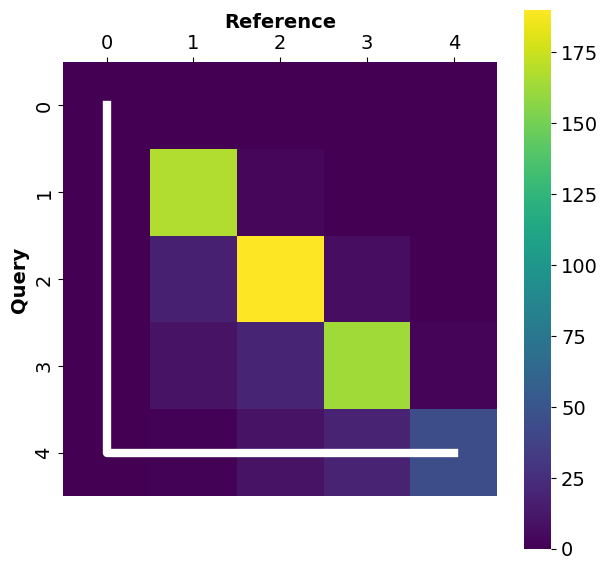

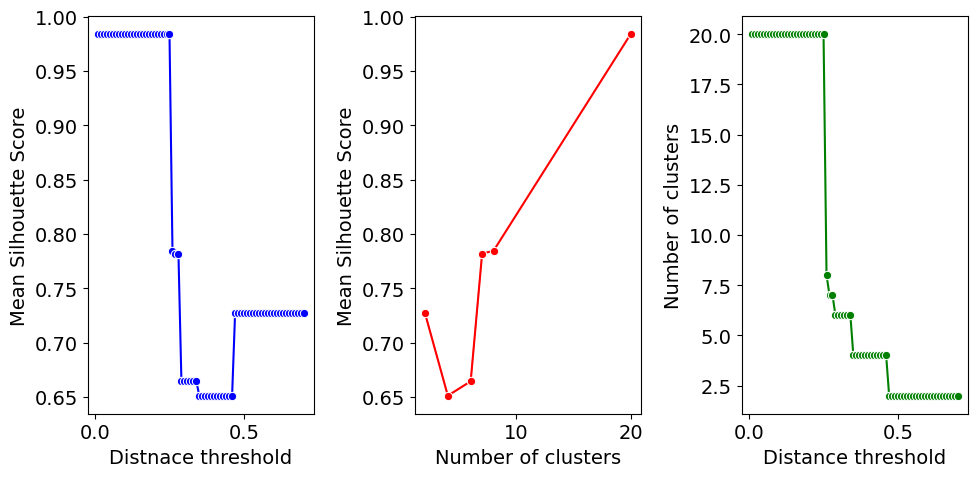

<Figure size 700x700 with 0 Axes>

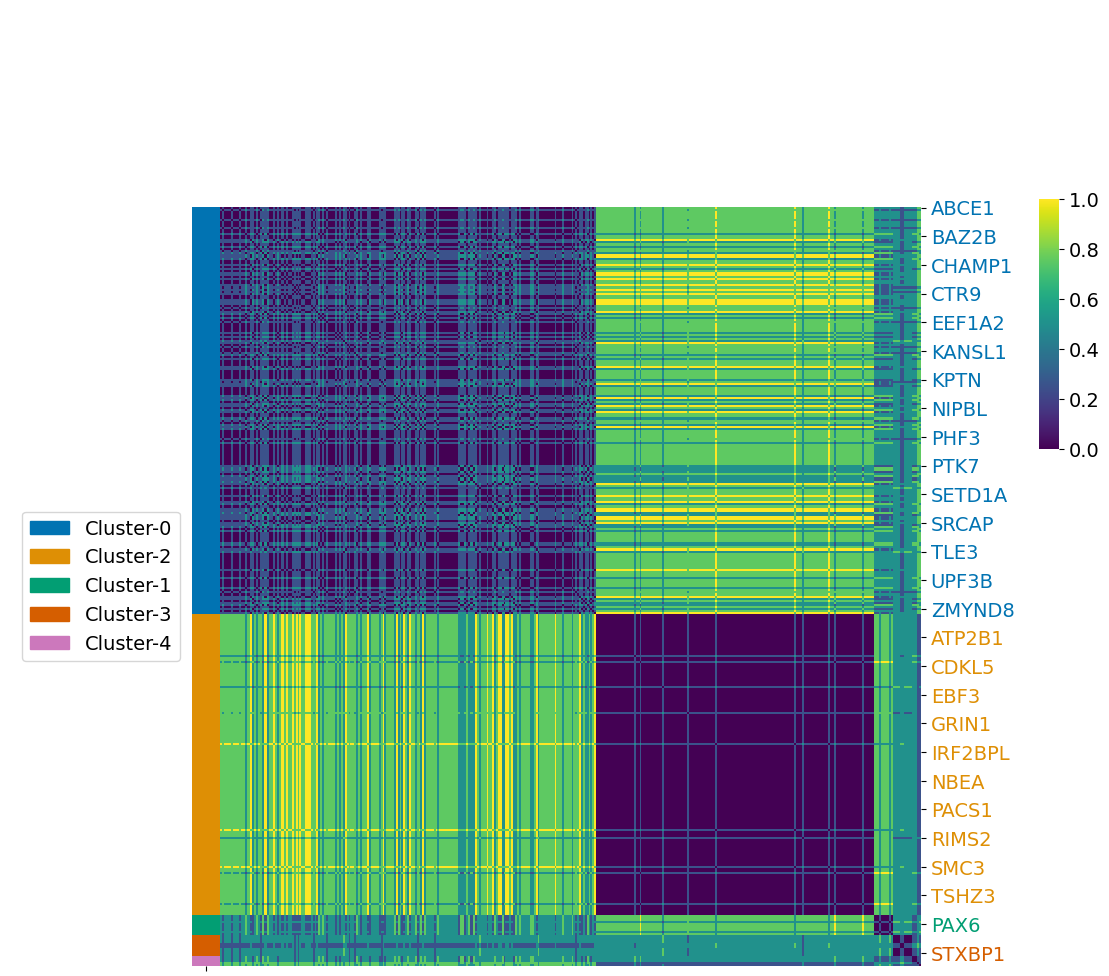

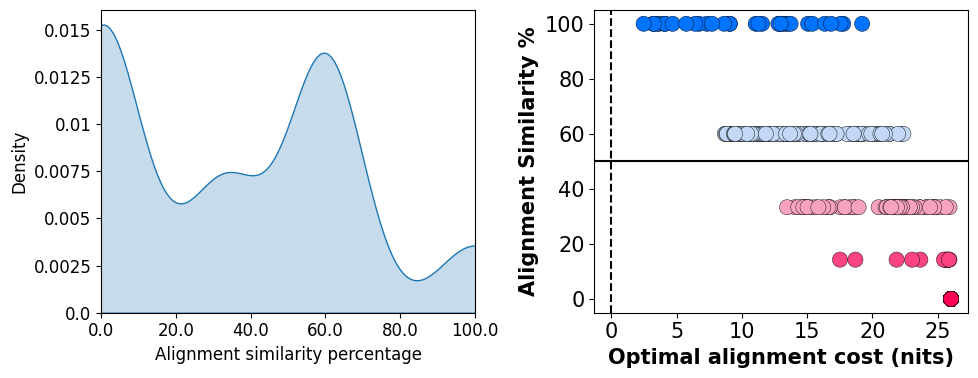

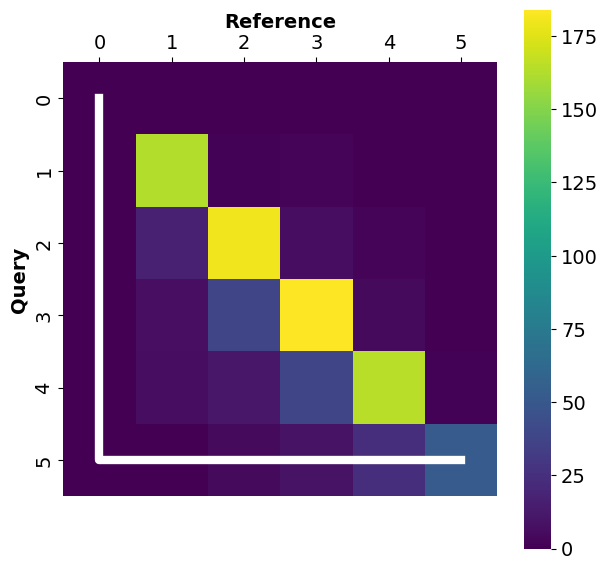

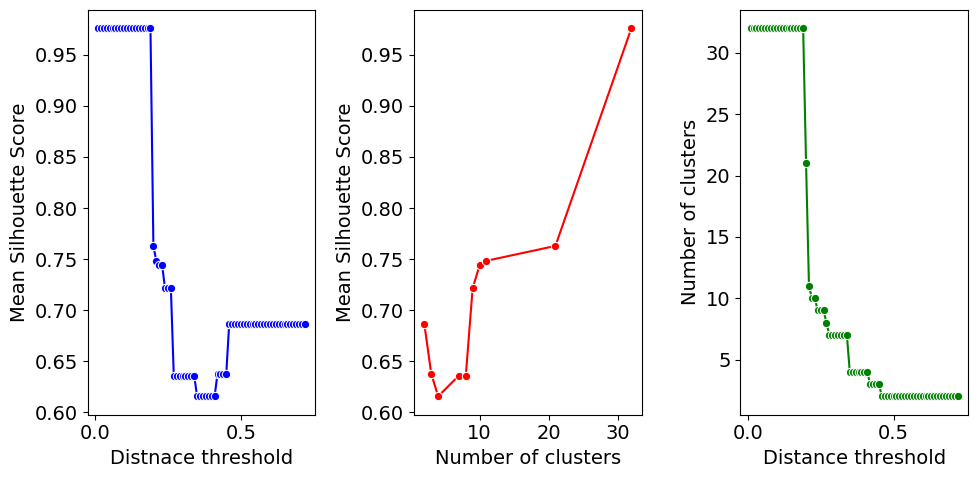

<Figure size 700x700 with 0 Axes>

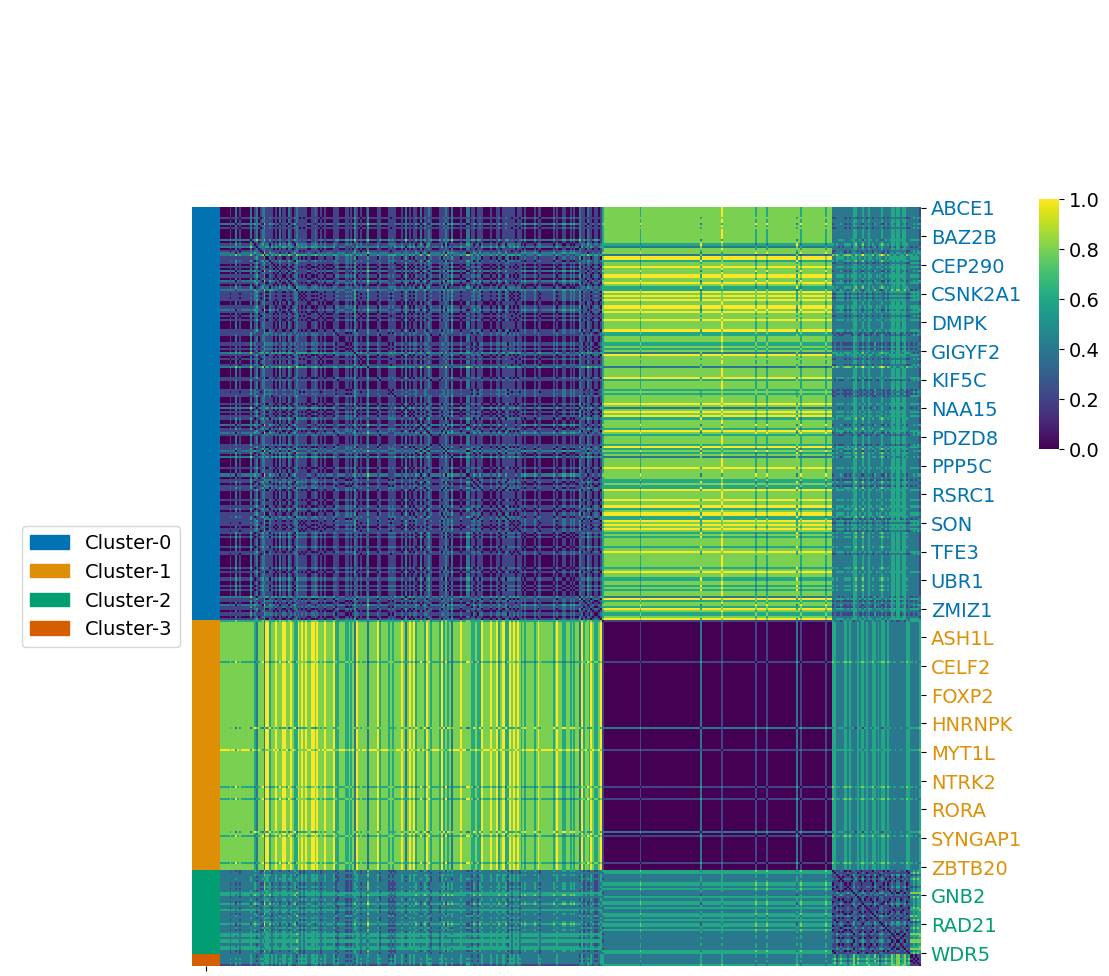

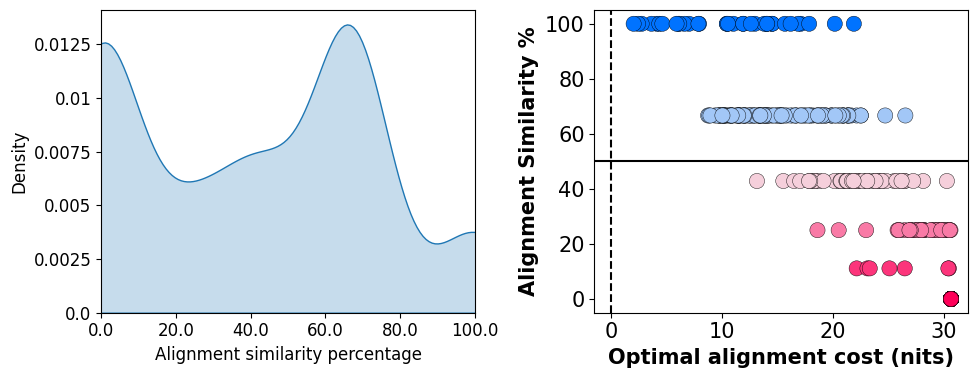

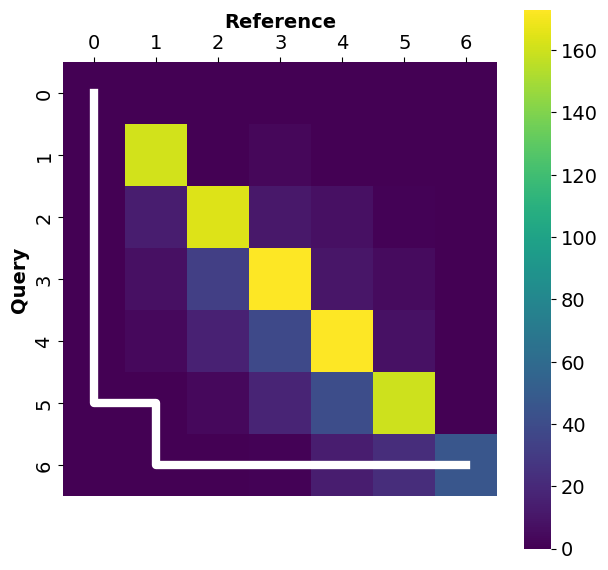

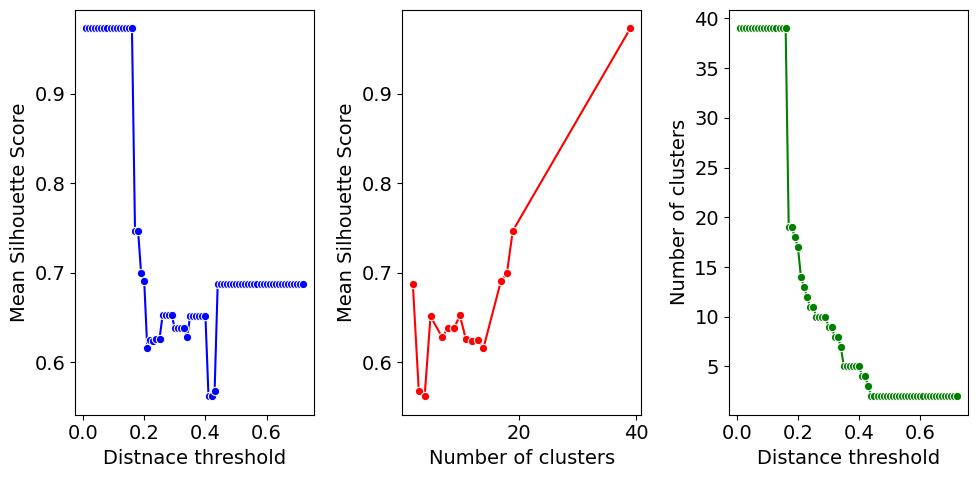

<Figure size 700x700 with 0 Axes>

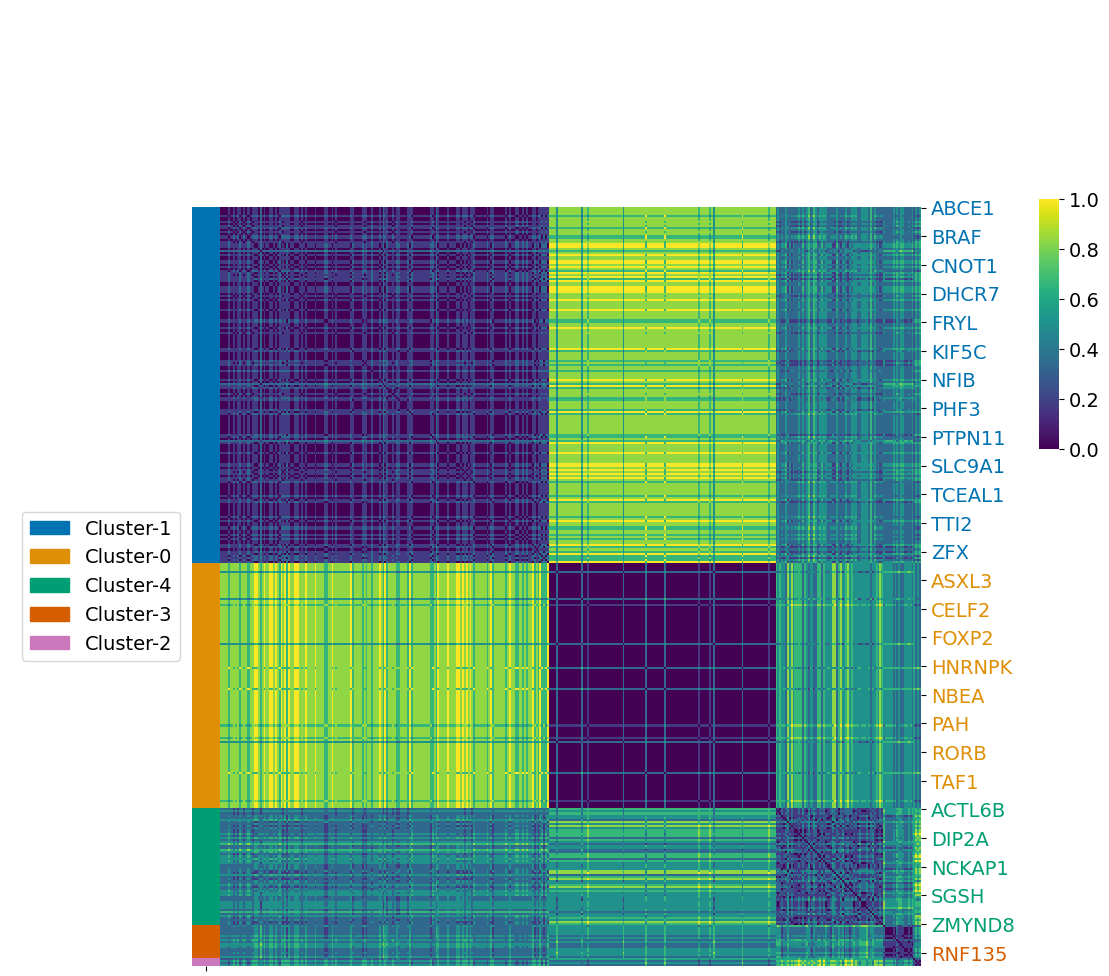

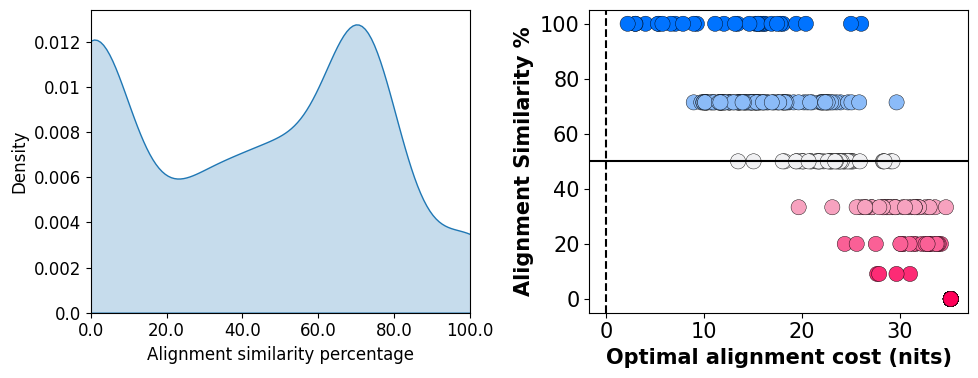

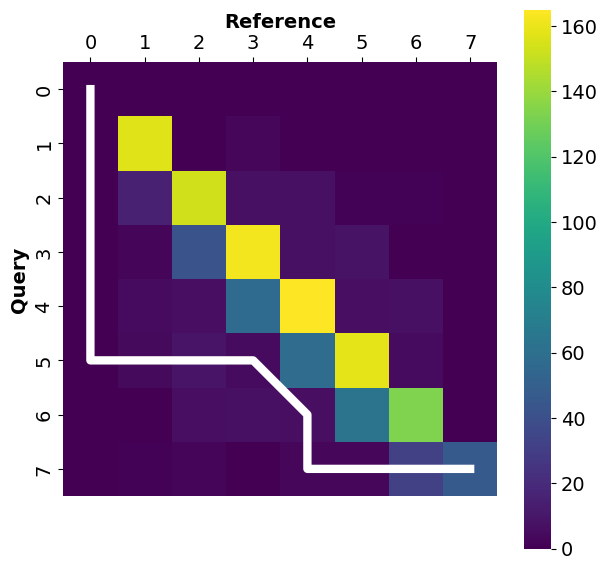

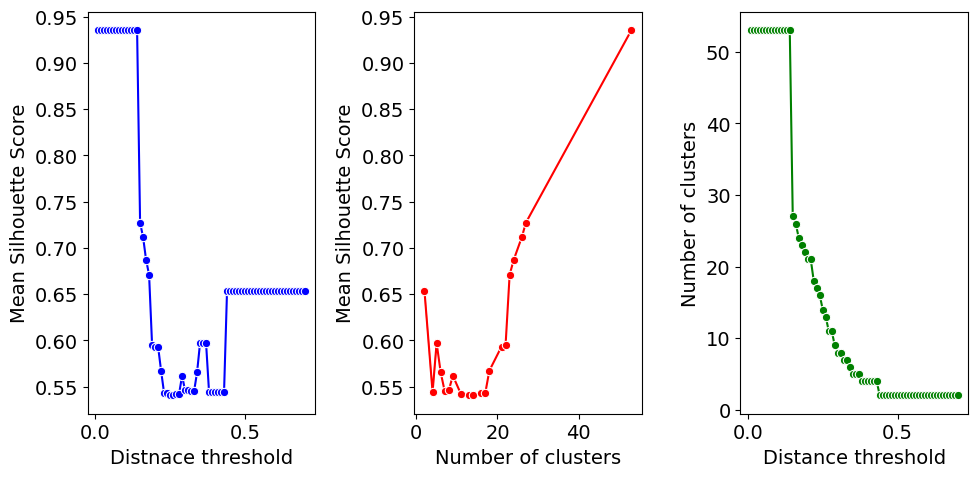

<Figure size 700x700 with 0 Axes>

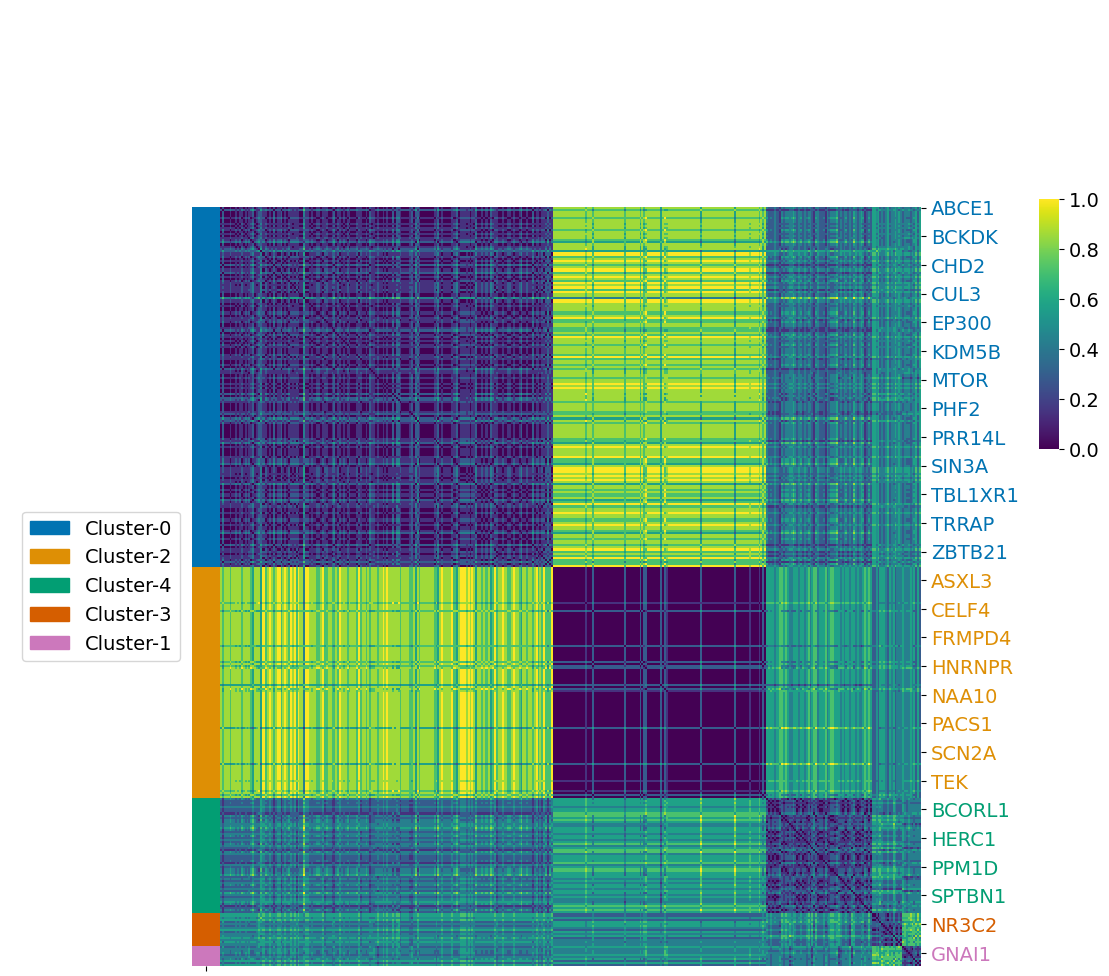

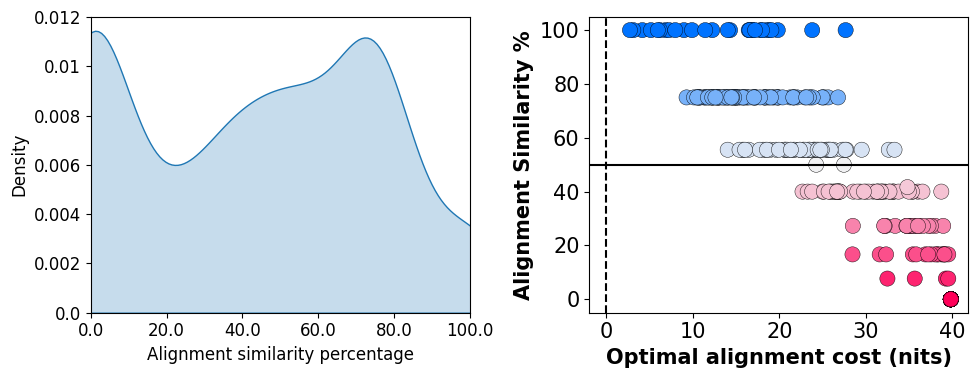

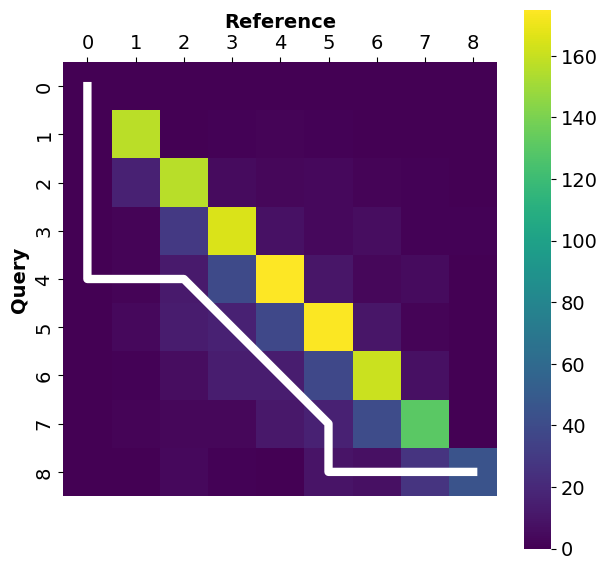

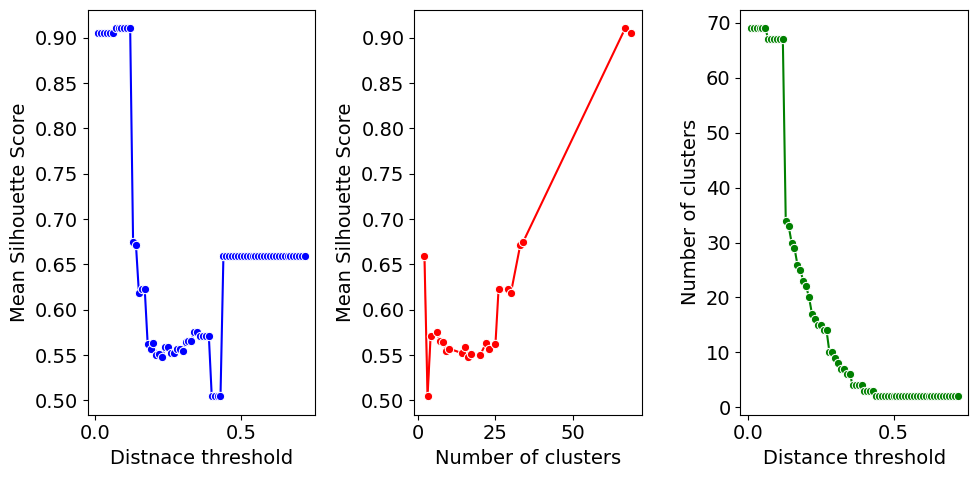

<Figure size 700x700 with 0 Axes>

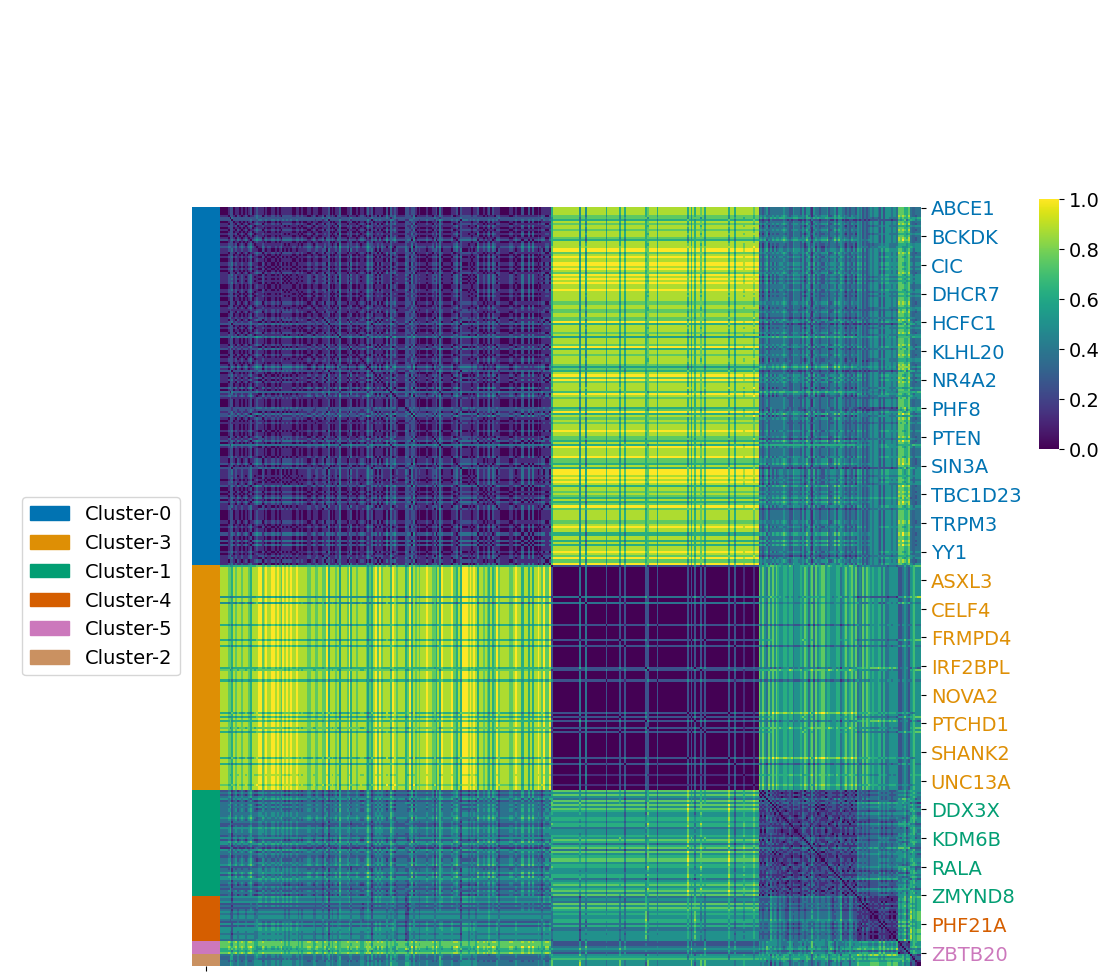

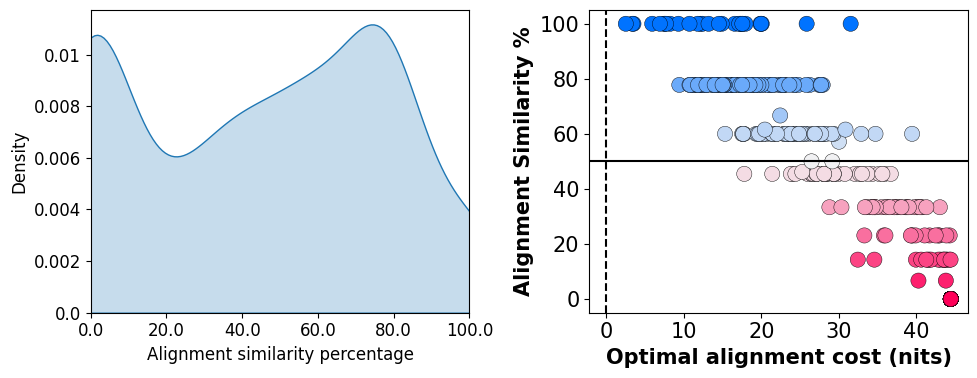

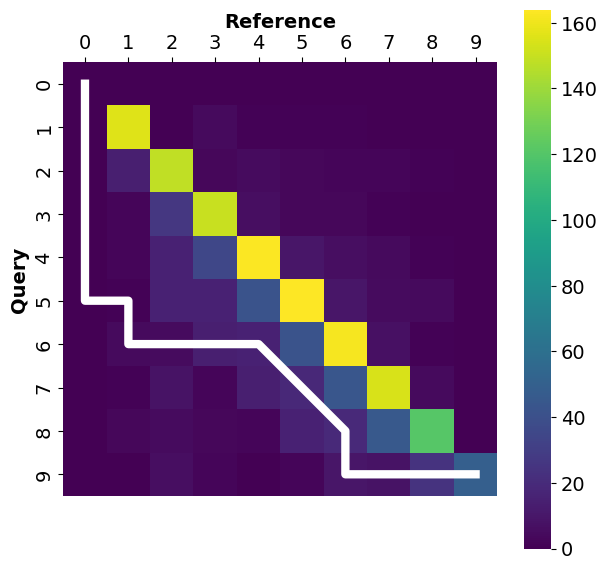

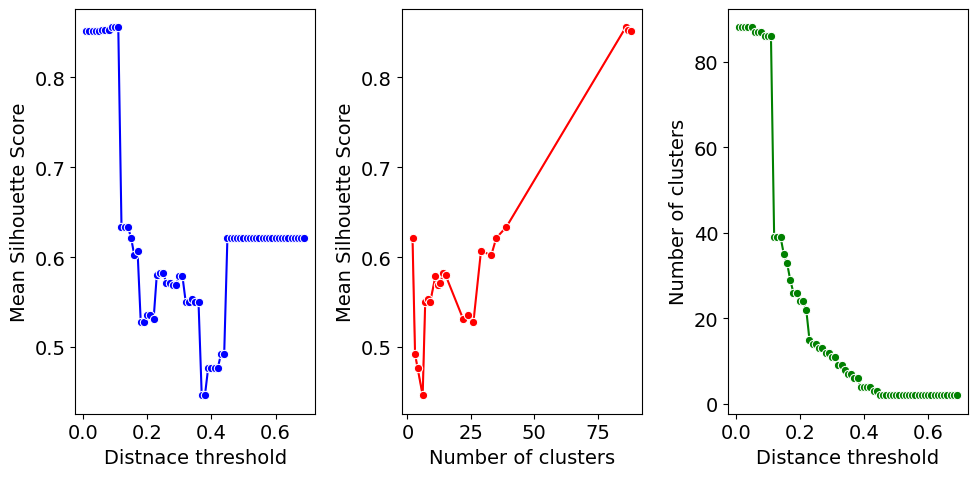

<Figure size 700x700 with 0 Axes>

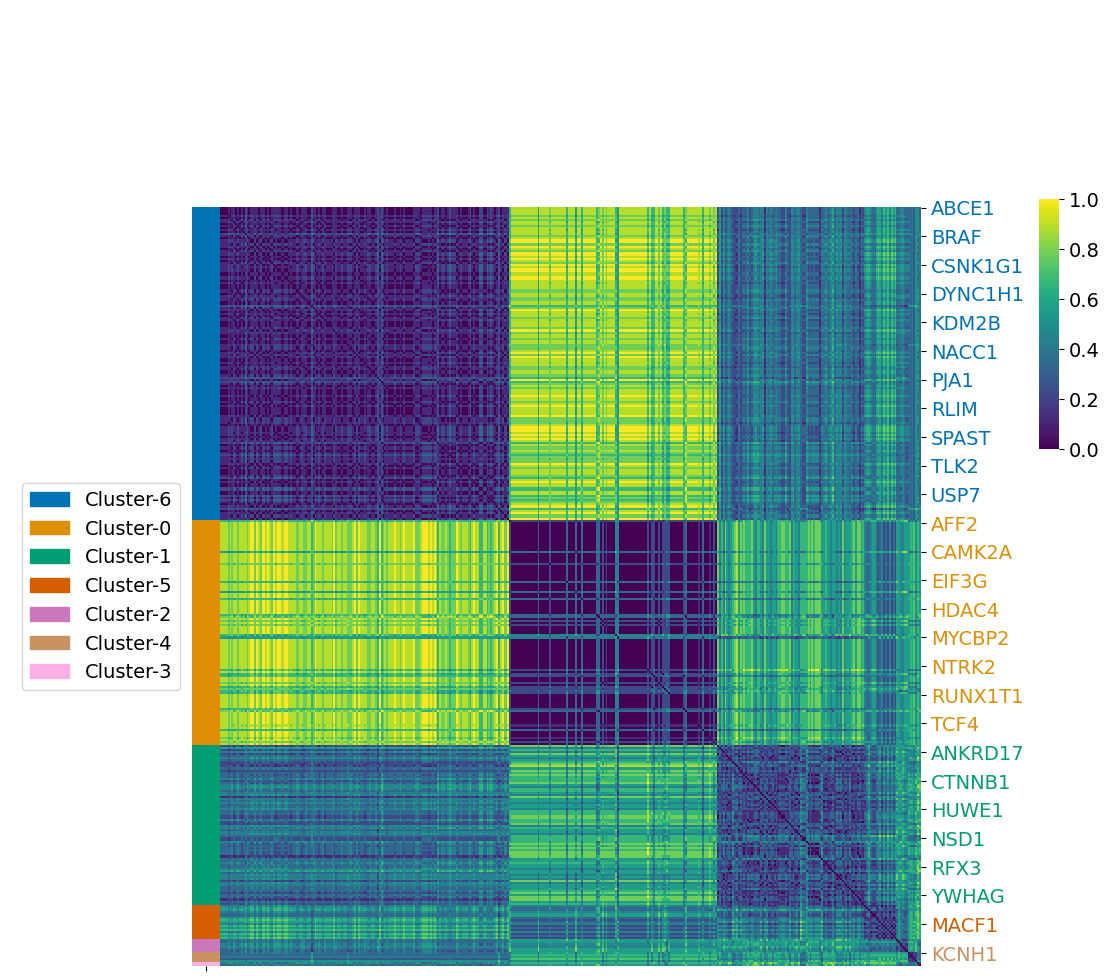

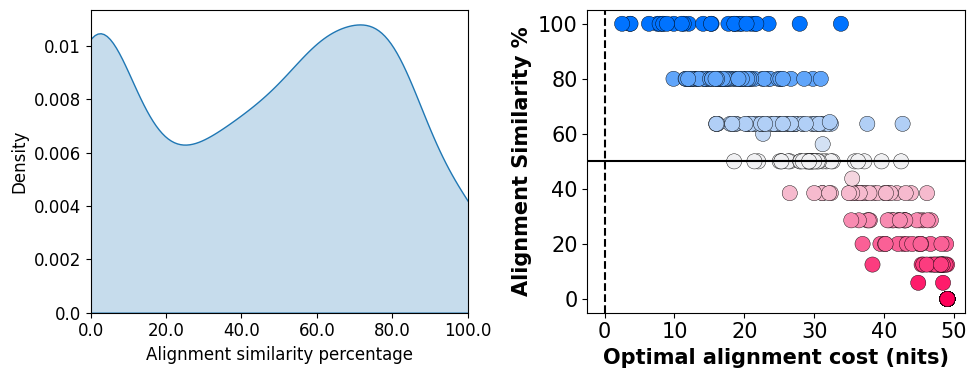

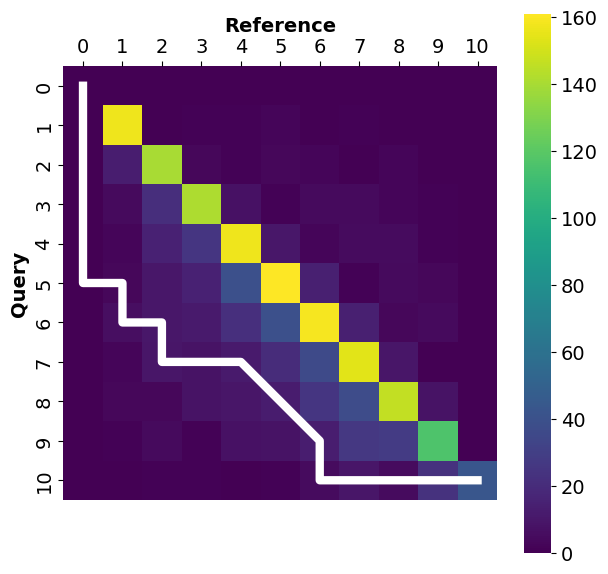

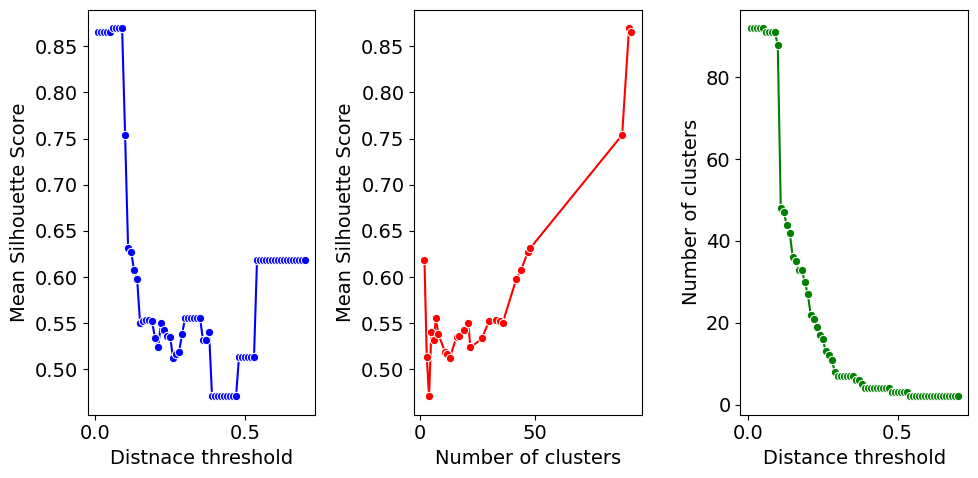

<Figure size 700x700 with 0 Axes>

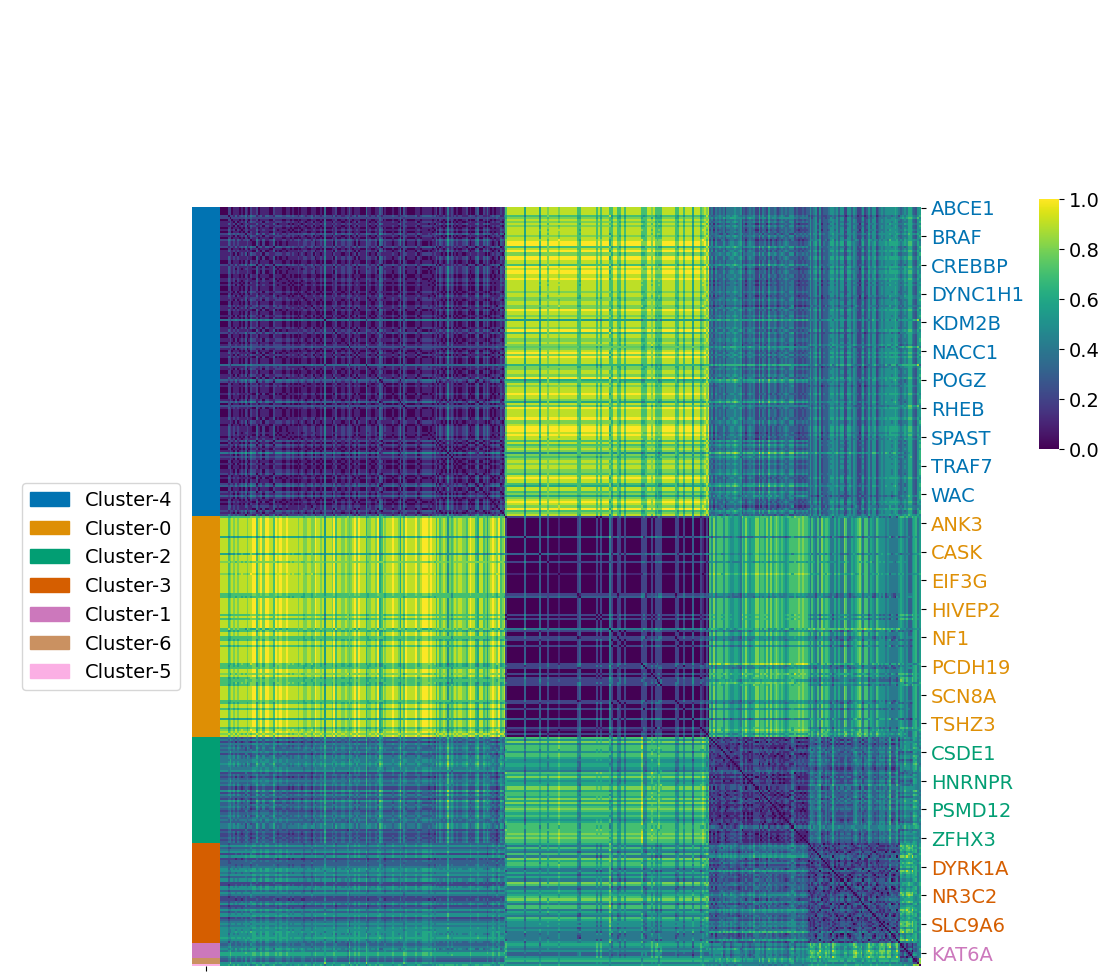

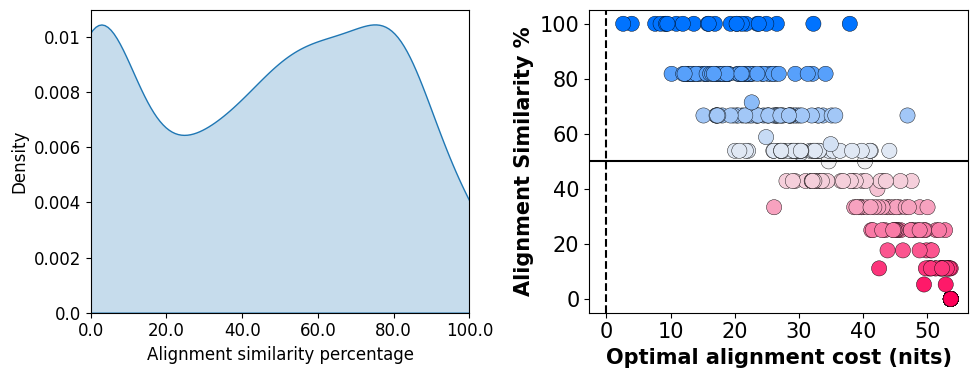

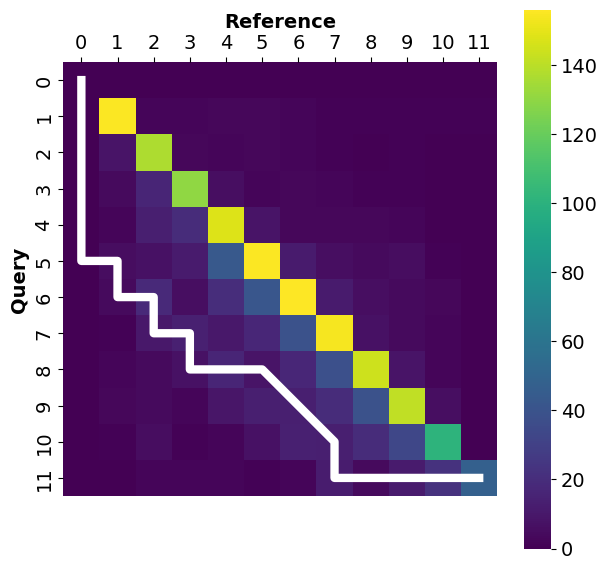

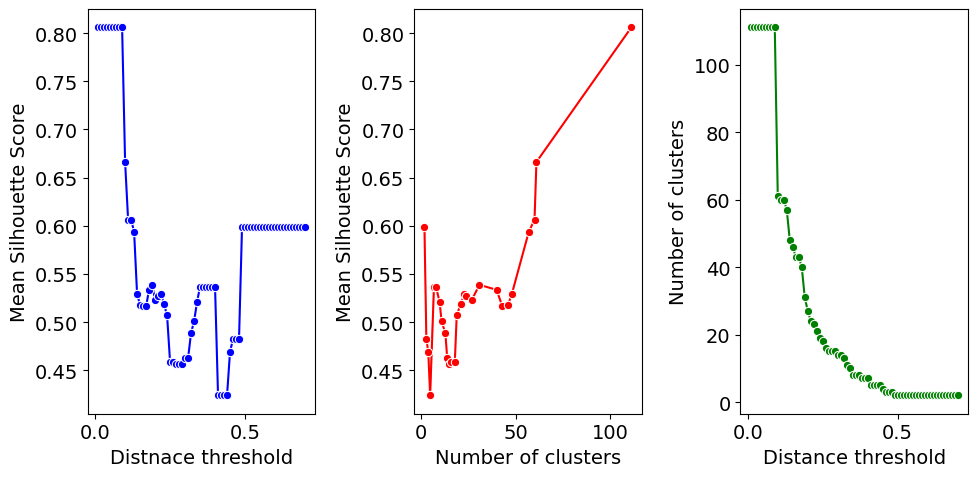

<Figure size 700x700 with 0 Axes>

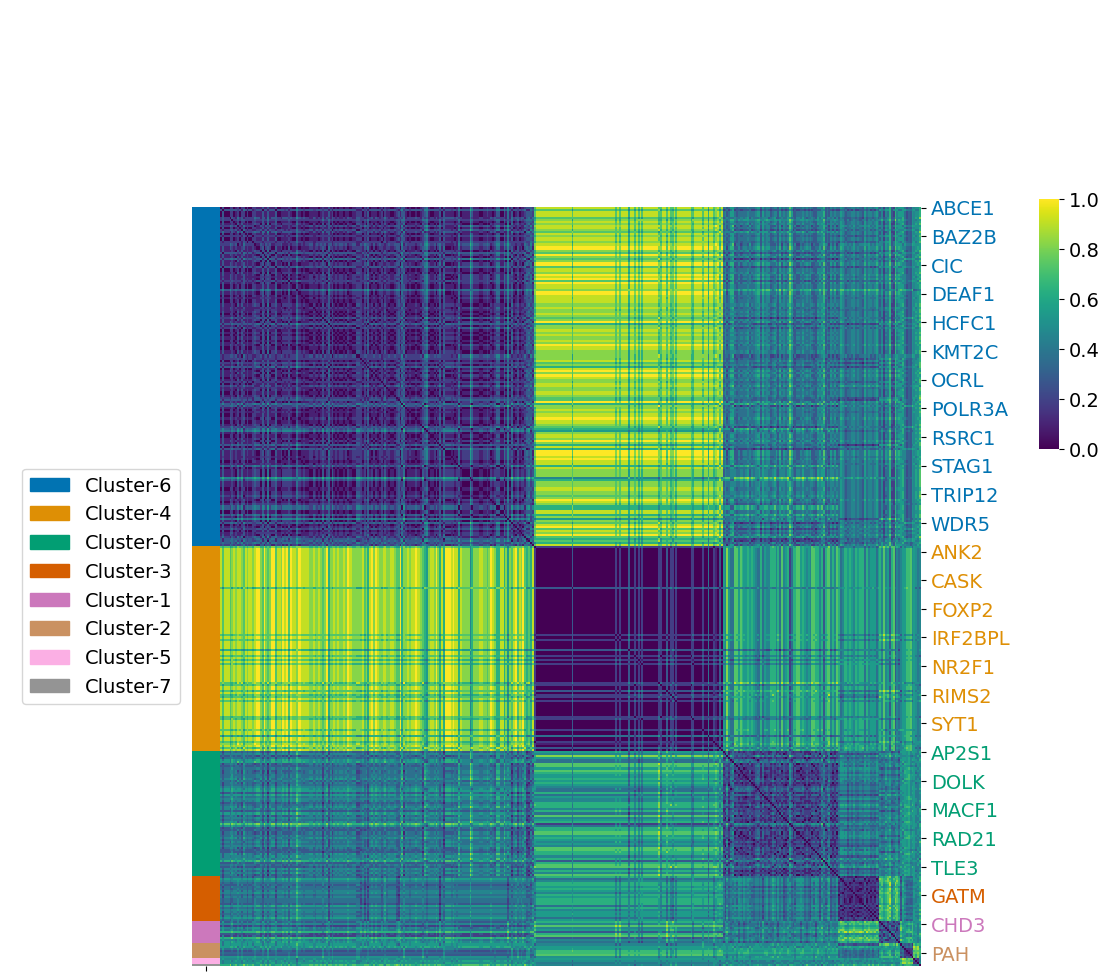

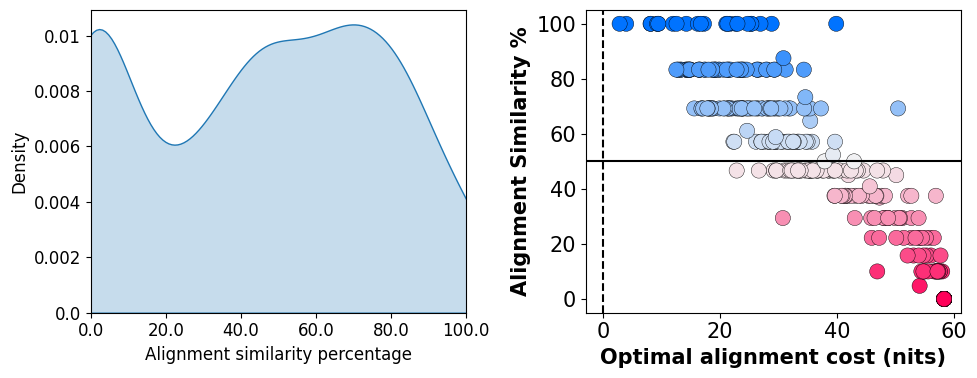

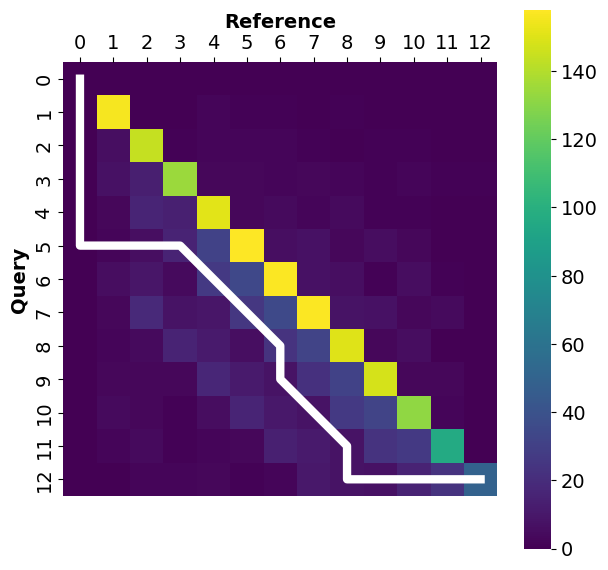

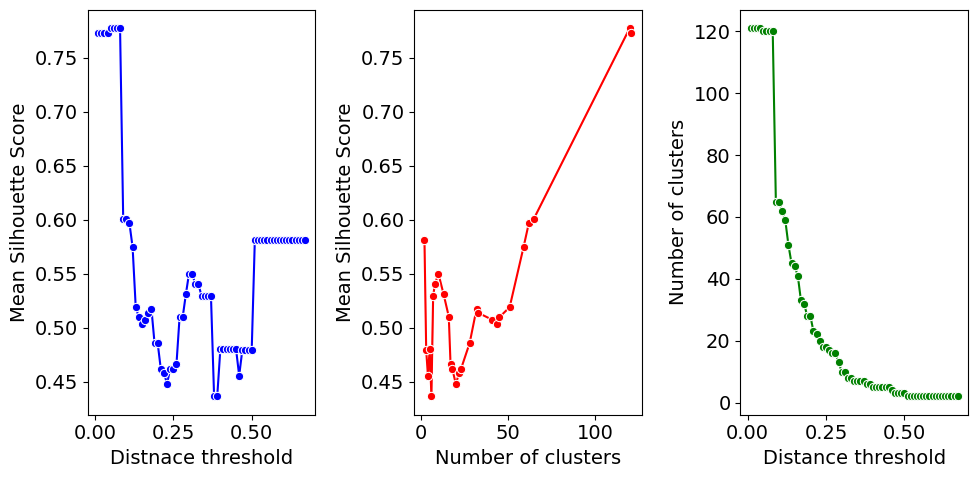

<Figure size 700x700 with 0 Axes>

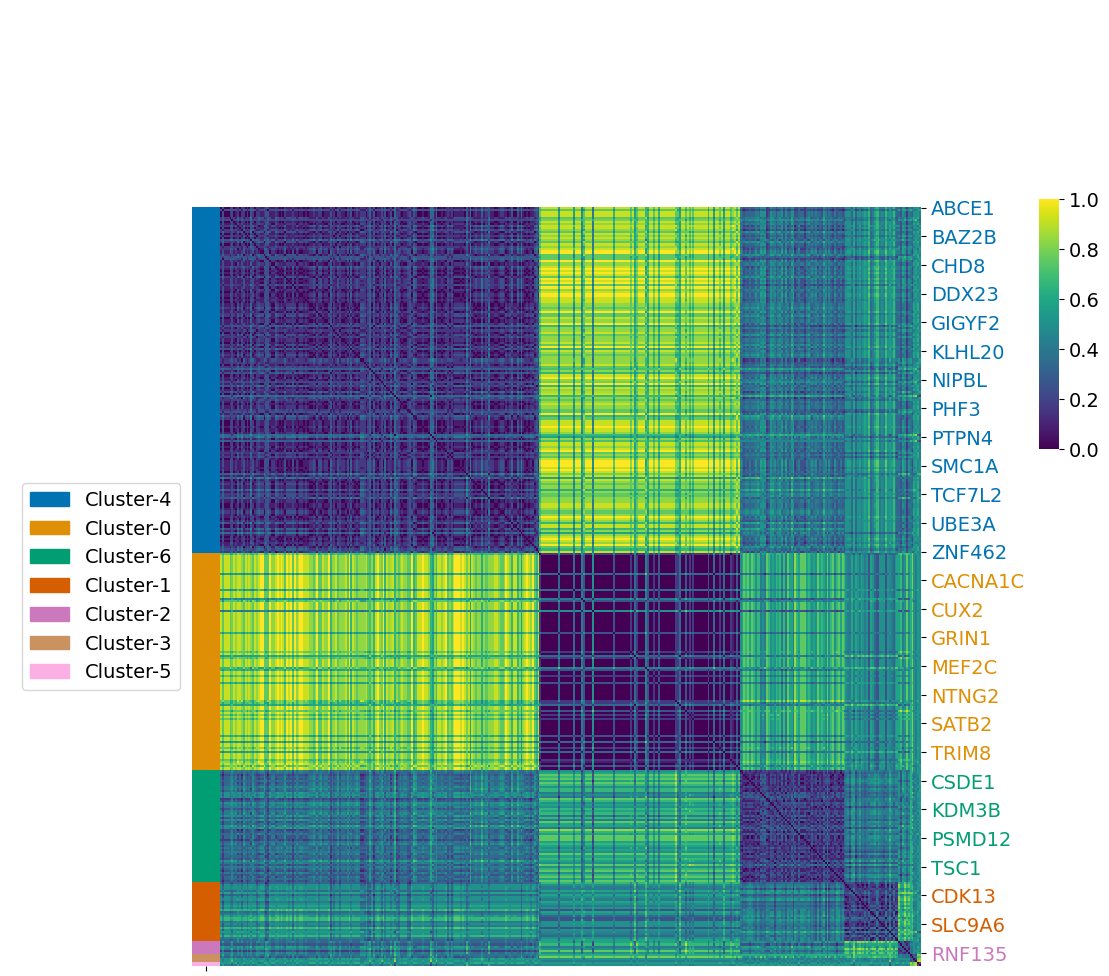

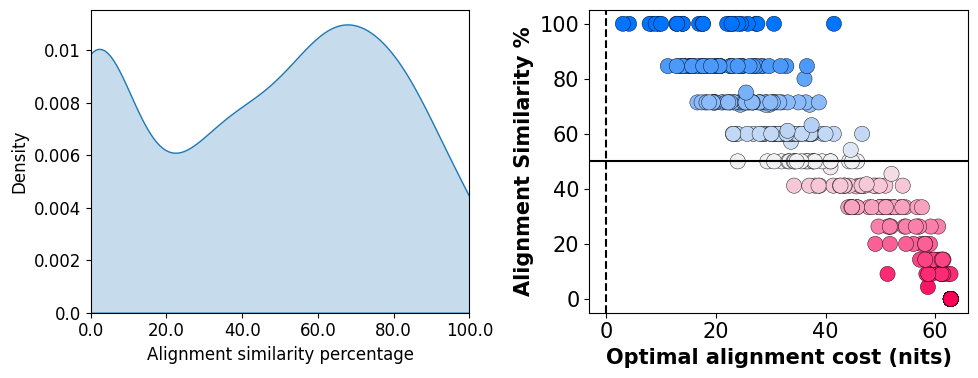

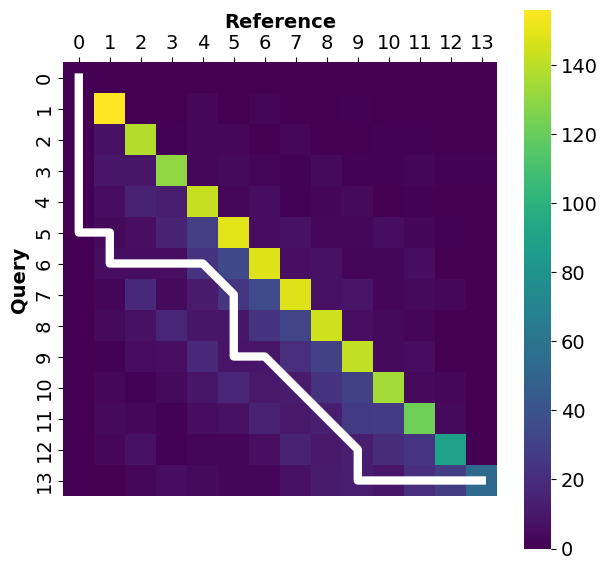

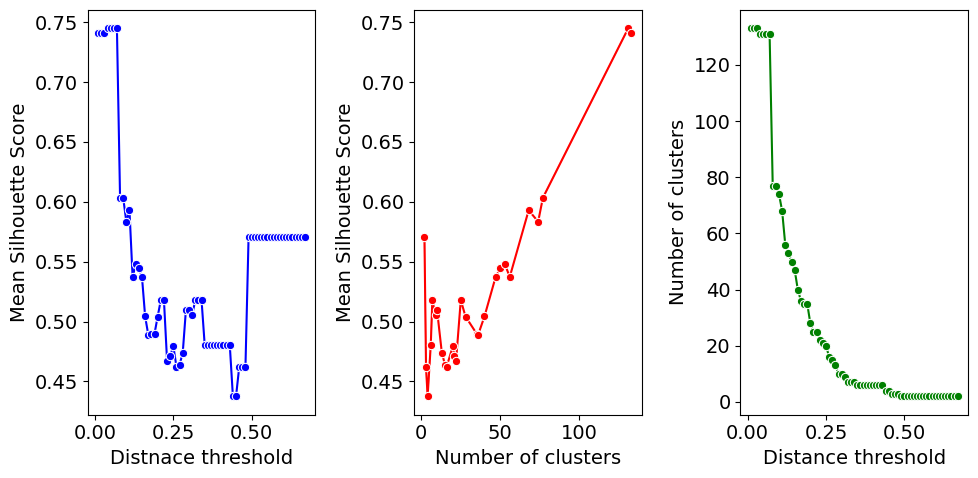

<Figure size 700x700 with 0 Axes>

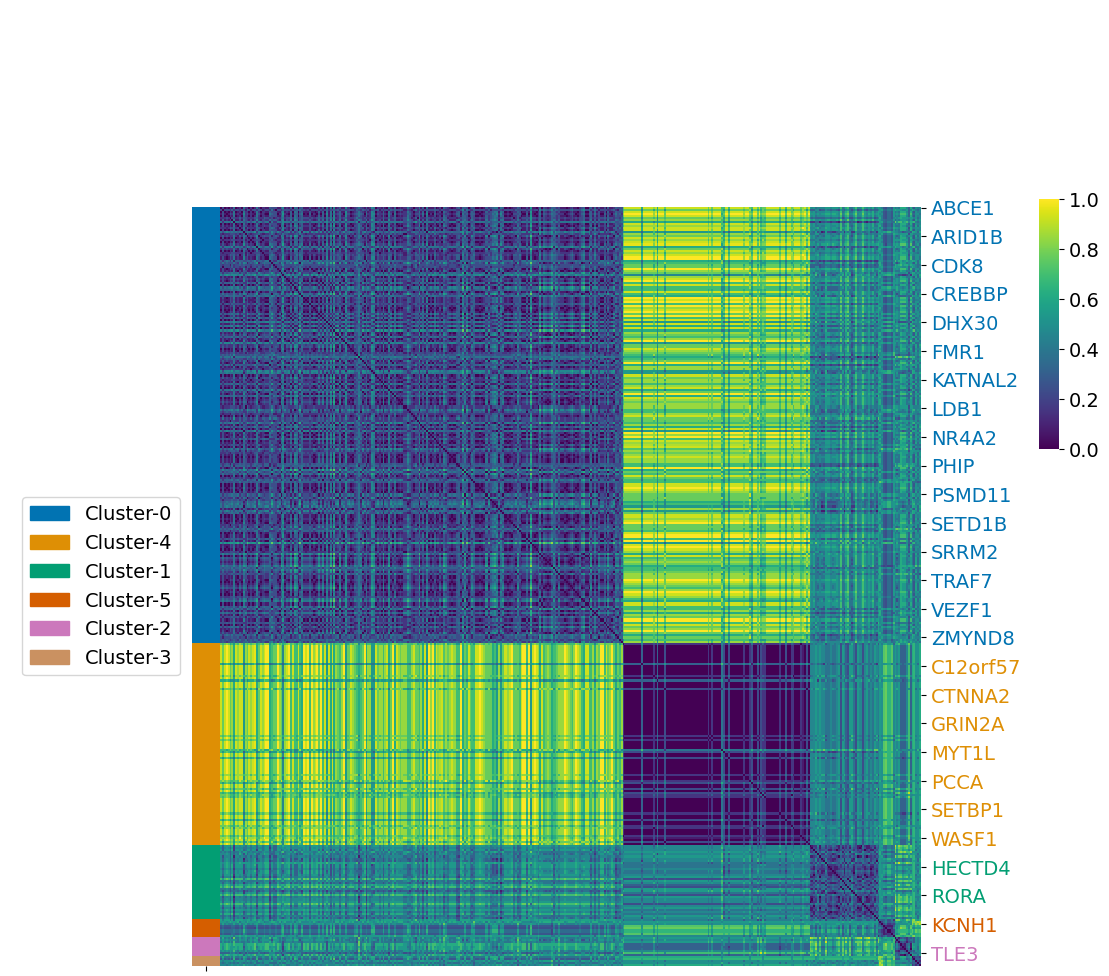

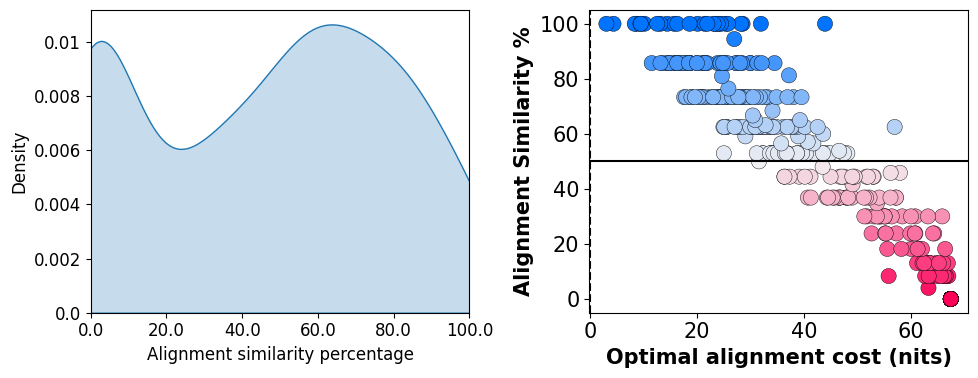

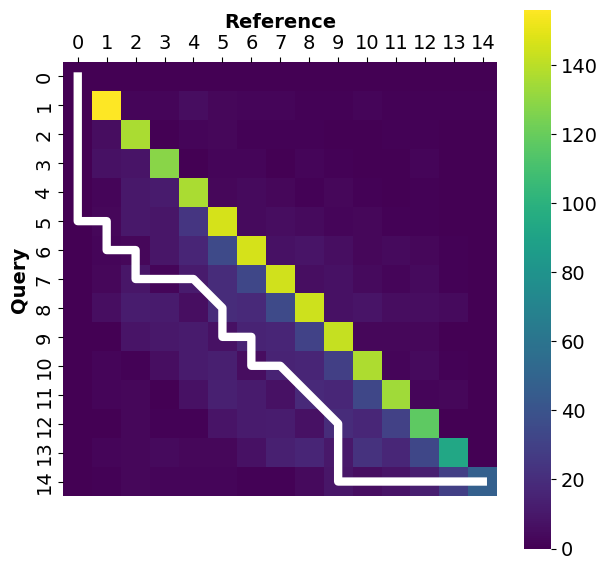

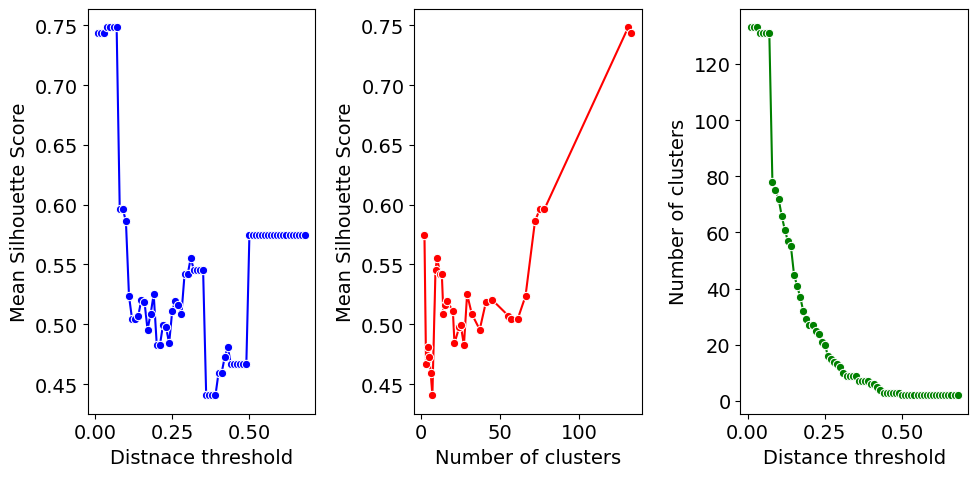

<Figure size 700x700 with 0 Axes>

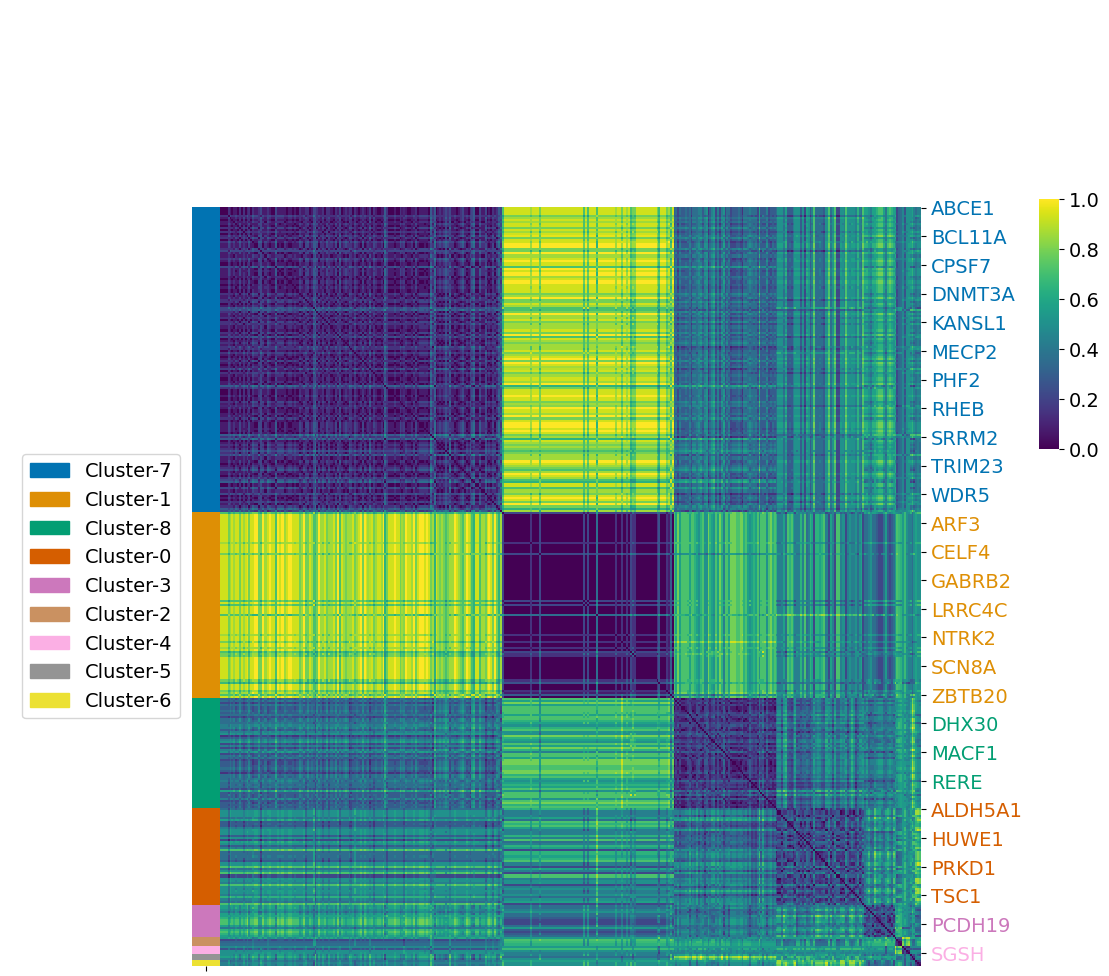

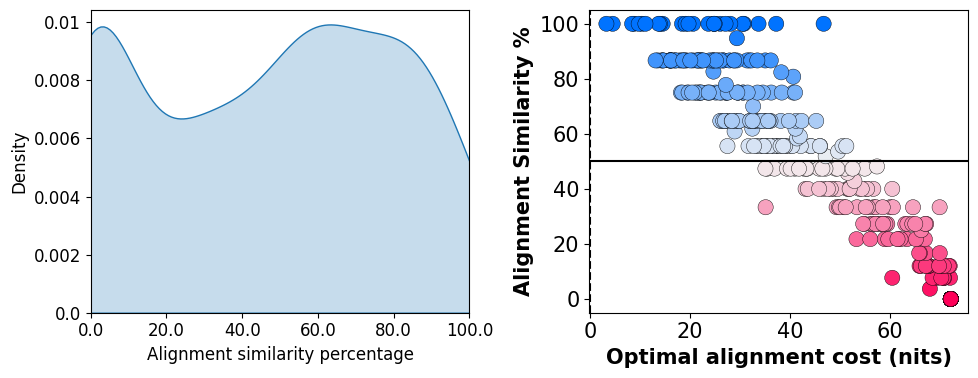

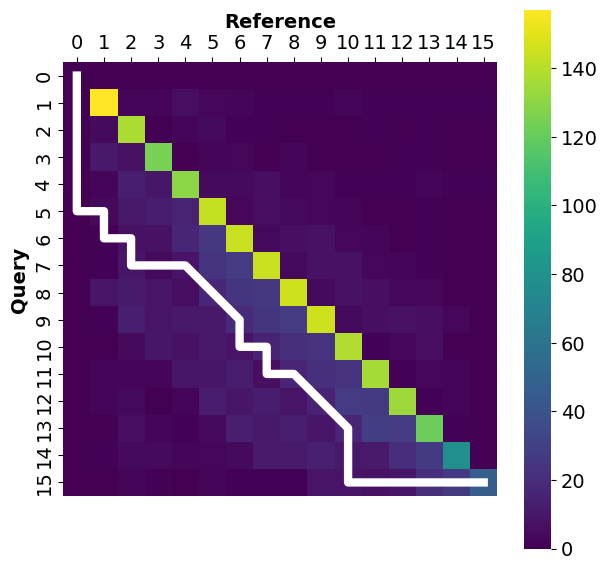

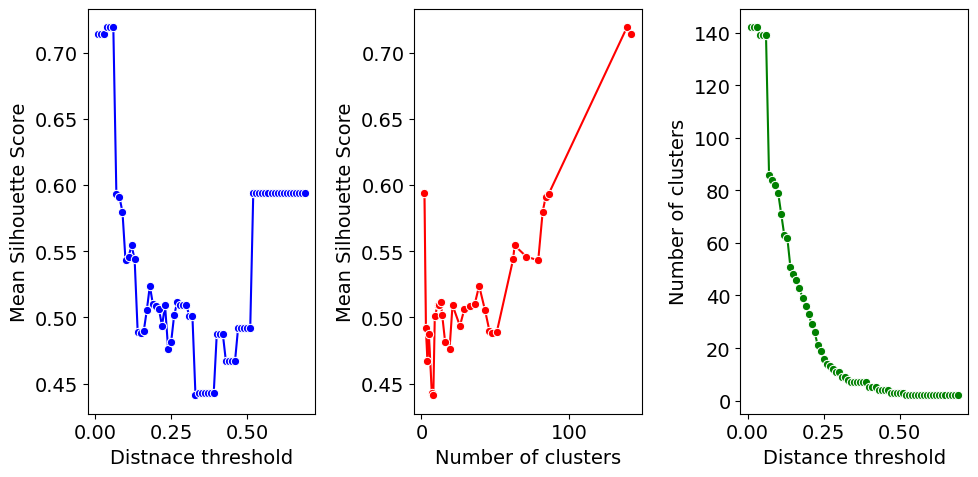

<Figure size 700x700 with 0 Axes>

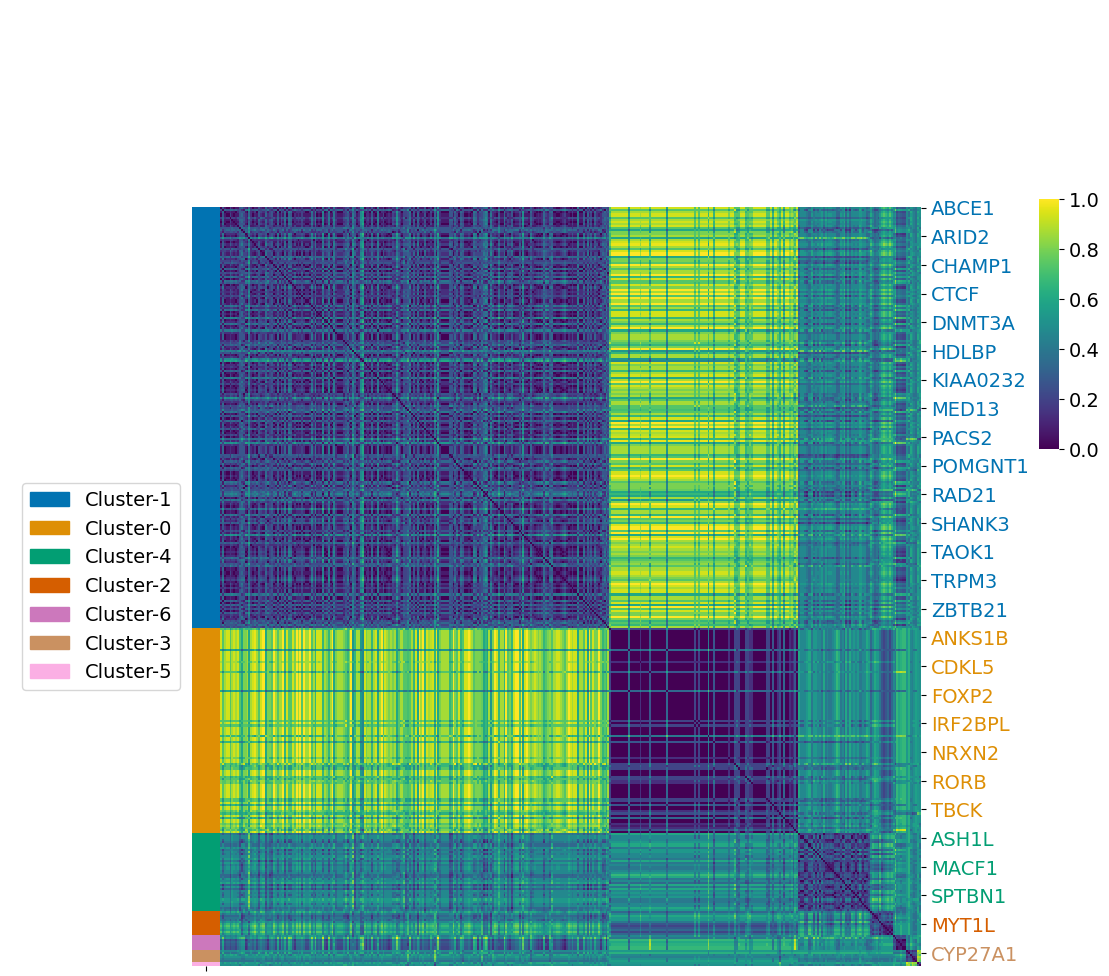

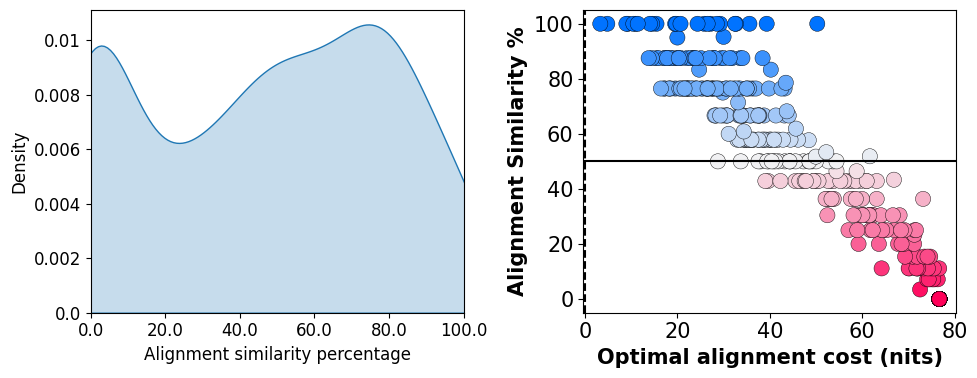

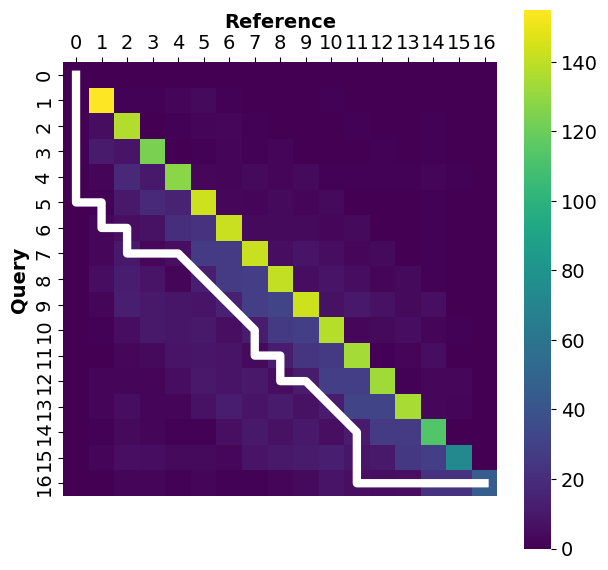

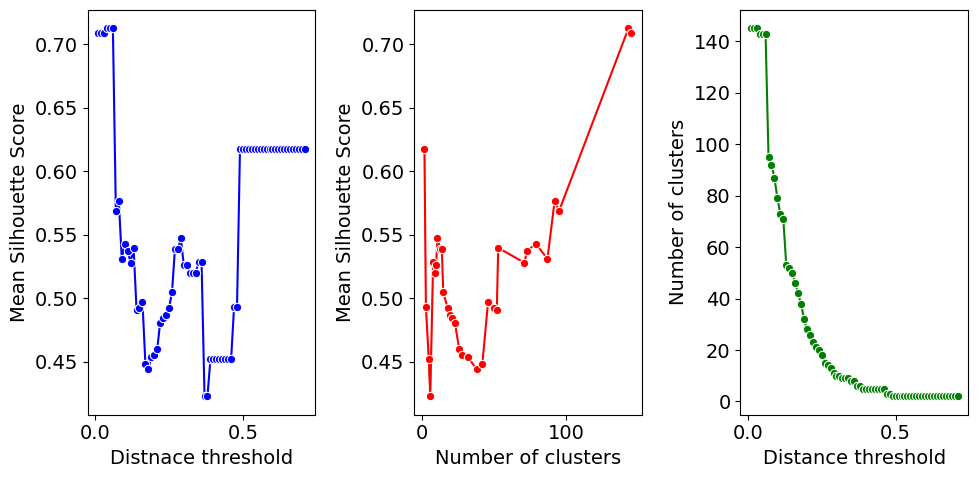

<Figure size 700x700 with 0 Axes>

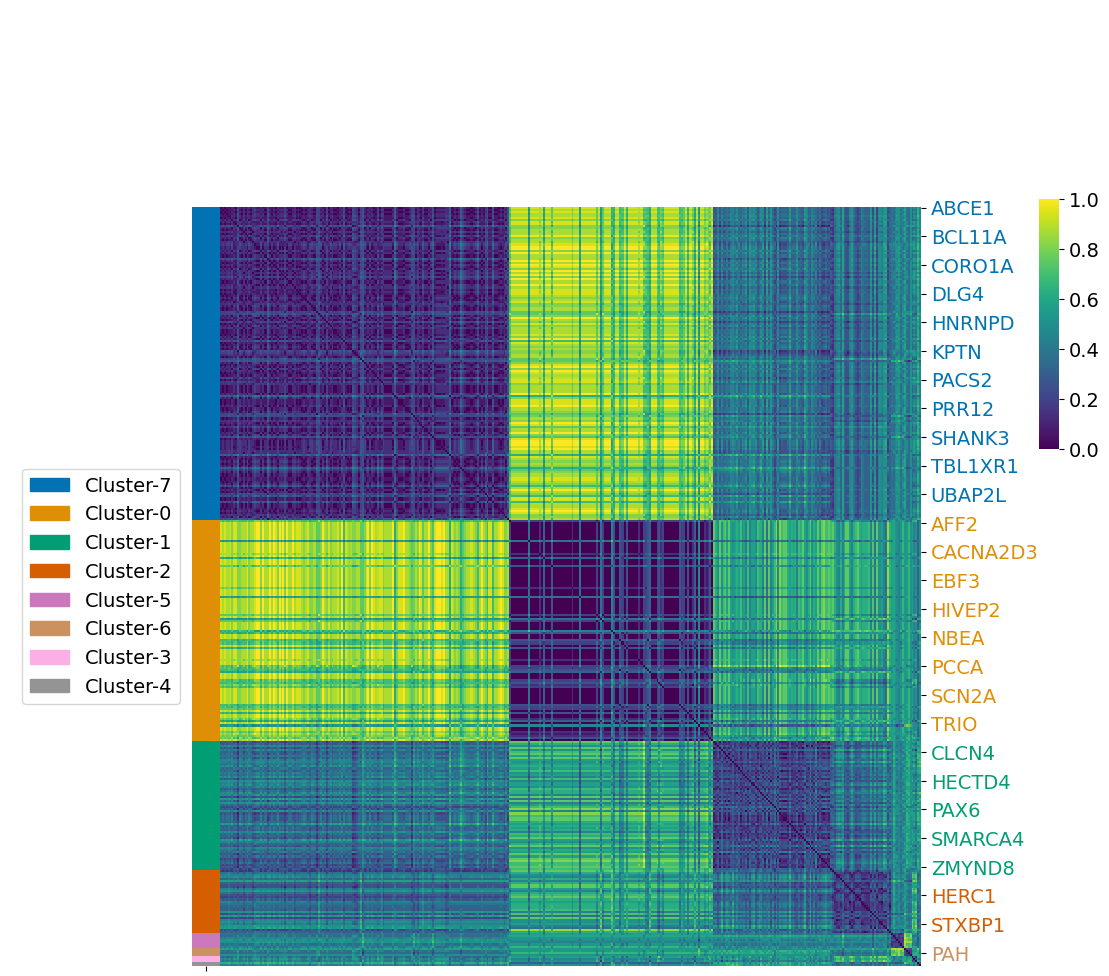

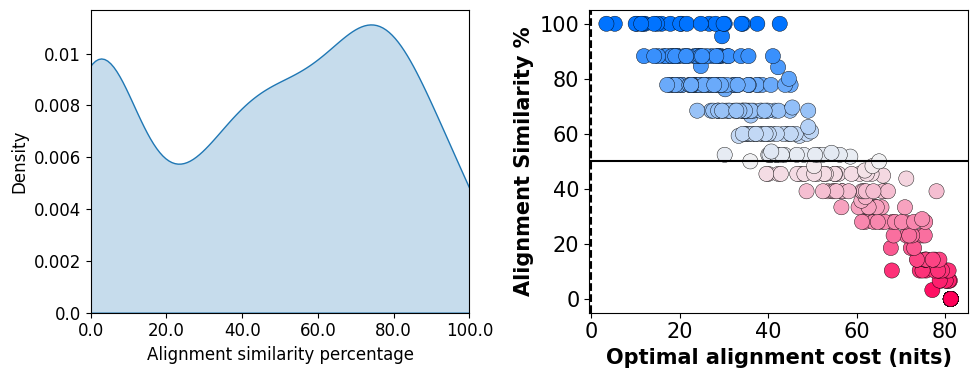

In [110]:

for n_bins in [4,5,6,7,8,9,10,11,12,13,14,15,16]:
#for n_bins in [14]:

    aligner = Main.RefQueryAligner(adata_ref, adata_query, gene_list, n_bins) #

    aligner.align_all_pairs() 
    #Aggregate (average) cell-level alignment across all aligned genes
    aligner.get_aggregate_alignment() 

    # cluster

    df = ClusterUtils.run_clustering(aligner, metric='hamming', experiment_mode=True) 
    ClusterUtils.run_clustering(aligner, metric='hamming', DIST_THRESHOLD=0.35) 
    plt.figure(figsize=(7, 7))  # 8 inches wide and 6 inches tall
    VisualUtils.plot_distmap_with_clusters(aligner)
    #plt.savefig('./figures/g2g_Cluster.pdf', format='pdf', bbox_inches='tight')  # Save as PDF

    ClusterUtils.print_cluster_average_alignments(aligner)

    df_cluster = pd.DataFrame.from_dict(aligner.gene_clusters, orient='index').transpose()
    #df_cluster

    df_cluster.columns= list(map(aligner.gene_clusters_average_alignments.get, df_cluster.columns.tolist()))

    df_cluster.to_csv(f'data/G2G/G2G_en_goldstein_psyad_sfari_{n_bins}.txt', sep='\t', index=False, header=True)
    df_sim = aligner.get_stat_df() # ordered genes according to alignment similarity statistics 
    df_sim.to_csv(f'data/G2G/G2G_en_goldstein_psyad_sfari_{n_bins}_similarity.txt', sep='\t', index=False, header=True)




In [55]:
df_sim

,Gene,alignment_similarity_percentage,opt_alignment_cost,l2fc,color,abs_l2fc
118,FRMPD4,0.0,72.073285,7.1196,red,7.1196
198,NLGN4X,0.0,72.073285,6.945501,red,6.945501
130,GRIN1,0.0,72.073285,6.735519,red,6.735519
187,NAA10,0.0,72.073285,-6.589702,red,6.589702
68,CNKSR2,0.0,72.073285,6.589355,red,6.589355
...,...,...,...,...,...,...
202,NR4A2,1.0,11.836233,-0.09987,green,0.09987
288,SLC45A1,1.0,7.180773,0.096332,green,0.096332
50,CCNK,1.0,10.972552,0.093124,green,0.093124
88,DEAF1,1.0,23.875917,0.076557,green,0.076557


<Figure size 300x800 with 0 Axes>

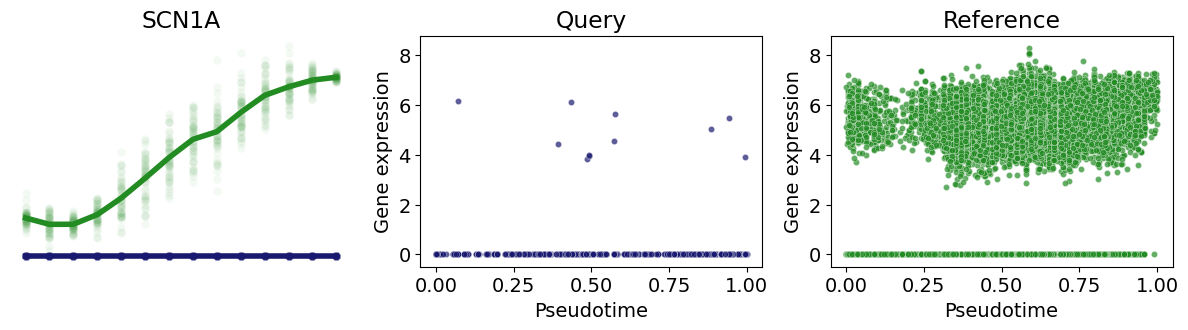

<Figure size 300x800 with 0 Axes>

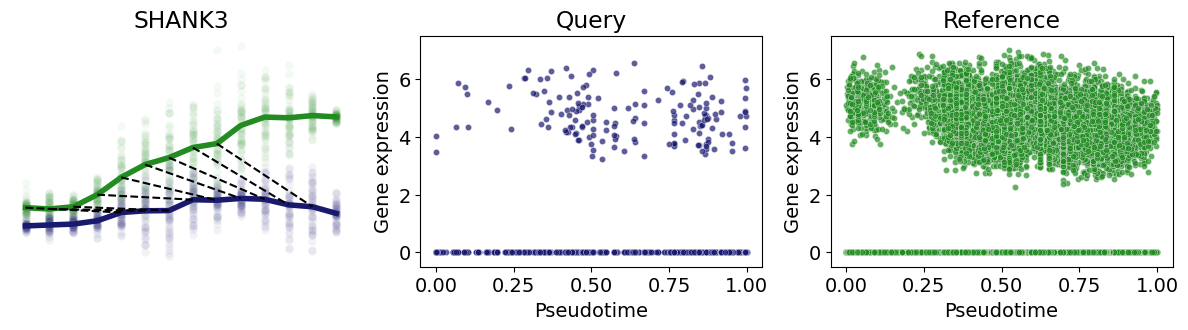

<Figure size 300x800 with 0 Axes>

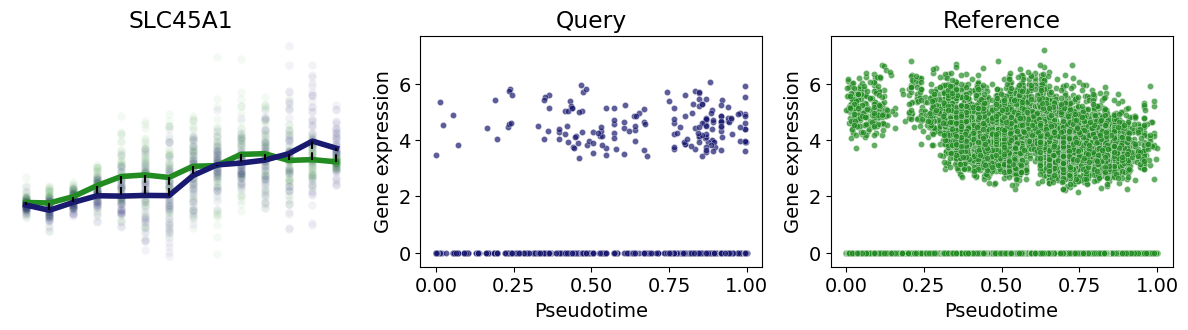

In [75]:
# # To access the genes in a particular cluster
# VisualUtils.plotTimeSeries('TCF4', aligner, plot_cells=True)
# gene_obj = aligner.results_map['TCF4']
# alignment_str = gene_obj.alignment_str
#print(alignment_str)
#IL1RAPL1, NRXN3, PCDHB2, PCDHB3, PCDHB10, PCDHB16, WNT5A
plt.figure(figsize=(3, 8))  # 8 inches wide and 6 inches tall
VisualUtils.plotTimeSeries('SCN1A', aligner, plot_cells=True)
plt.savefig('./figures/NC/SCN1A_exp.pdf', format='pdf', bbox_inches='tight')  # Save as PDF


plt.figure(figsize=(3, 8))  # 8 inches wide and 6 inches tall
VisualUtils.plotTimeSeries('SHANK3', aligner, plot_cells=True)
plt.savefig('./figures/NC/SHANK3_exp.pdf', format='pdf', bbox_inches='tight')  # Save as PDF


plt.figure(figsize=(3, 8))  # 8 inches wide and 6 inches tall
VisualUtils.plotTimeSeries('SLC45A1', aligner, plot_cells=True)
plt.savefig('./figures/NC/SLC45A1_exp.pdf', format='pdf', bbox_inches='tight')  # Save as PDF

# plt.figure(figsize=(3, 8))  # 8 inches wide and 6 inches tall
# VisualUtils.plotTimeSeries('CTCF', aligner, plot_cells=True)
# plt.savefig('./figures/SHANK3_exp.pdf', format='pdf', bbox_inches='tight')  # Save as PDF

# plt.figure(figsize=(3, 8))  # 8 inches wide and 6 inches tall
# VisualUtils.plotTimeSeries('CCNK', aligner, plot_cells=True)
# #plt.savefig('./figures/SHANK3_exp.pdf', format='pdf', bbox_inches='tight')  # Save as PDF



# plt.figure(figsize=(3, 8))  # 8 inches wide and 6 inches tall
# VisualUtils.plotTimeSeries('NR4A2', aligner, plot_cells=True)
# #plt.savefig('./figures/SHANK3_exp.pdf', format='pdf', bbox_inches='tight')  # Save as PDF



# gene_obj = aligner.results_map['SHANK3']
# alignment_str = gene_obj.alignment_str
# print(alignment_str)

# #'ABLIM2', 'ACAT2', 'ACTN1', 'ADAM21'
# # # To print all gene alignments in the cluster
# # aligner.show_cluster_alignment_strings(cluster_id)